# 차원 축소 알고리즘 적용 실무 프로젝트

## 프로젝트 개요

인터넷에서 공개 데이터셋을 다운로드하여 차원 축소 알고리즘을 적용하는 실무형 노트북입니다.

## 사용 데이터셋

- 데이터셋: UCI Wine Quality - Red Wine
- 데이터 URL: https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv
- 입력 변수: 와인의 화학적 특성
- 목표 변수: `quality`
- 실무 목표: 와인 품질을 저품질, 중간품질, 고품질로 분류

## 적용 알고리즘

1. PCA
2. LDA
3. t-SNE
4. UMAP
5. Autoencoder

## 전체 흐름

```text
인터넷 데이터 다운로드
→ 데이터 확인
→ 품질 점수 클래스 변환
→ Train/Test 분리
→ 표준화
→ 기준 모델 학습
→ PCA 적용
→ LDA 적용
→ t-SNE/UMAP 시각화
→ Autoencoder 차원 축소
→ 성능 비교
```


In [1]:

# ============================================================
# 1. 실습 환경 준비
# ============================================================

# UMAP 알고리즘을 사용하기 위한 패키지를 설치합니다.
# UMAP은 sklearn 기본 패키지에 포함되어 있지 않기 때문에 별도 설치가 필요합니다.
# -q 옵션은 설치 로그를 간단히 출력하라는 의미입니다.
!pip -q install umap-learn

# ============================================================
# 2. 기본 데이터 처리 라이브러리 불러오기
# ============================================================

# numpy는 숫자 배열, 행렬 계산, 난수 생성 등에 사용하는 핵심 수치 계산 라이브러리입니다.
# 머신러닝 데이터는 대부분 숫자 배열 형태로 처리되므로 거의 항상 사용됩니다.
import numpy as np

# pandas는 CSV, Excel 같은 표 형식 데이터를 읽고 처리하는 라이브러리입니다.
# DataFrame이라는 표 구조를 사용하여 컬럼 선택, 결측치 확인, 통계량 확인 등을 쉽게 할 수 있습니다.
import pandas as pd

# matplotlib.pyplot은 그래프를 그리는 라이브러리입니다.
# PCA, LDA, t-SNE, UMAP, Autoencoder 결과를 2차원 산점도로 시각화할 때 사용합니다.
import matplotlib.pyplot as plt

# ============================================================
# 3. 머신러닝 전처리 및 모델 관련 라이브러리 불러오기
# ============================================================

# train_test_split은 전체 데이터를 학습 데이터와 테스트 데이터로 나누는 함수입니다.
# 모델이 학습하지 않은 데이터에서도 잘 맞추는지 확인하기 위해 사용합니다.
from sklearn.model_selection import train_test_split

# StandardScaler는 각 입력 변수의 평균을 0, 표준편차를 1로 맞추는 표준화 도구입니다.
# 차원 축소 알고리즘은 변수 단위 차이에 민감하므로 표준화가 중요합니다.
from sklearn.preprocessing import StandardScaler

# PCA는 Principal Component Analysis, 즉 주성분 분석입니다.
# 정답 라벨 없이 데이터의 분산이 큰 방향을 찾아 차원을 줄이는 비지도 차원 축소 알고리즘입니다.
from sklearn.decomposition import PCA

# LDA는 Linear Discriminant Analysis, 즉 선형 판별 분석입니다.
# 정답 라벨을 사용하여 클래스가 잘 분리되는 방향으로 차원을 줄이는 지도학습 기반 차원 축소 알고리즘입니다.
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# TSNE는 t-SNE 알고리즘입니다.
# 고차원 데이터에서 가까운 샘플들이 2차원에서도 가깝게 배치되도록 시각화하는 비선형 차원 축소 알고리즘입니다.
from sklearn.manifold import TSNE

# umap은 UMAP 알고리즘을 사용하기 위한 라이브러리입니다.
# UMAP은 t-SNE와 비슷하게 고차원 데이터를 2차원으로 시각화하지만, 보통 속도가 빠르고 대용량 데이터에 더 유리합니다.
import umap

# RandomForestClassifier는 여러 개의 의사결정나무를 결합한 앙상블 분류 모델입니다.
# 차원 축소 전후의 분류 성능을 비교하기 위해 사용합니다.
from sklearn.ensemble import RandomForestClassifier

# LogisticRegression은 선형 분류 모델입니다.
# 기준 성능 비교용으로 사용하기 좋습니다.
from sklearn.linear_model import LogisticRegression

# accuracy_score는 전체 예측 중 맞춘 비율, 즉 정확도를 계산합니다.
# classification_report는 precision, recall, f1-score 등 상세 평가 지표를 출력합니다.
# confusion_matrix는 실제 클래스와 예측 클래스의 대응 관계를 행렬로 보여줍니다.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# 4. PyTorch 딥러닝 라이브러리 불러오기
# ============================================================

# torch는 PyTorch의 핵심 라이브러리입니다.
# Tensor 생성, GPU 연산, 딥러닝 학습에 사용됩니다.
import torch

# torch.nn은 신경망 계층, 활성화 함수, 손실 함수 등을 제공합니다.
# Autoencoder 모델을 만들 때 사용합니다.
import torch.nn as nn

# torch.optim은 Adam, SGD 같은 최적화 알고리즘을 제공합니다.
# Autoencoder의 가중치를 업데이트할 때 사용합니다.
import torch.optim as optim

# TensorDataset은 입력 데이터와 정답 데이터를 하나의 데이터셋으로 묶습니다.
# DataLoader는 데이터를 batch 단위로 나누어 학습할 수 있게 해줍니다.
from torch.utils.data import TensorDataset, DataLoader

# ============================================================
# 5. 랜덤 시드 고정
# ============================================================

# 랜덤 시드를 고정하면 데이터를 나누거나 모델을 초기화할 때 가능한 한 같은 결과가 나오도록 만들 수 있습니다.
# 실습, 보고서, 수업에서는 재현성이 중요하므로 시드를 고정하는 것이 좋습니다.
SEED = 42

# numpy에서 사용하는 난수 시드를 고정합니다.
np.random.seed(SEED)

# PyTorch에서 사용하는 난수 시드를 고정합니다.
torch.manual_seed(SEED)

# torch.cuda.is_available()은 현재 환경에서 GPU 사용 가능 여부를 확인합니다.
# GPU가 있으면 "cuda", 없으면 "cpu"를 사용합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 준비 상태를 출력합니다.
print("라이브러리 준비 완료")
print("사용 장치:", device)


라이브러리 준비 완료
사용 장치: cpu


## 1단계. 인터넷에서 데이터셋 다운로드

UCI 공식 저장소의 Red Wine Quality CSV 파일을 인터넷에서 직접 읽습니다.

이 CSV 파일은 컬럼 구분자가 쉼표가 아니라 세미콜론(`;`)이므로 `sep=";"`를 지정해야 합니다.


In [2]:

# ============================================================
# 인터넷에서 CSV 데이터 다운로드
# ============================================================

# UCI Machine Learning Repository에서 제공하는 Red Wine Quality 데이터셋 URL입니다.
# 이 데이터셋은 와인의 화학적 성분과 품질 점수를 포함합니다.
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# pd.read_csv()는 CSV 파일을 DataFrame으로 읽어오는 pandas 함수입니다.
# 일반 CSV는 쉼표(,)로 컬럼이 구분되지만,
# 이 데이터셋은 세미콜론(;)으로 컬럼이 구분되어 있으므로 sep=";"를 반드시 지정해야 합니다.
# 인터넷 URL을 직접 넣으면 파일을 다운로드하지 않고도 바로 읽을 수 있습니다.
df = pd.read_csv(DATA_URL, sep=";")

# head()는 데이터 앞부분 5개 행을 보여줍니다.
# 데이터를 불러온 직후에는 컬럼명과 값 형태가 올바른지 먼저 확인해야 합니다.
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:

# ============================================================
# 데이터 기본 정보 확인
# ============================================================

# df.shape는 데이터의 행(row)과 열(column) 개수를 튜플 형태로 반환합니다.
# 예: (1599, 12)라면 1599개의 샘플과 12개의 컬럼이 있다는 의미입니다.
print("데이터 크기:", df.shape)

# df.columns.tolist()는 DataFrame의 컬럼명을 리스트로 변환합니다.
# 어떤 입력 변수가 있는지 확인할 때 사용합니다.
print("컬럼 목록:")
print(df.columns.tolist())

# df.info()는 각 컬럼의 데이터 타입, 결측치가 아닌 값의 개수, 메모리 사용량을 보여줍니다.
# 실무에서는 데이터 분석 시작 전에 반드시 확인하는 기본 정보입니다.
df.info()


데이터 크기: (1599, 12)
컬럼 목록:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality         

In [4]:

# ============================================================
# 기초 통계량 확인
# ============================================================

# describe()는 숫자형 컬럼의 주요 통계량을 출력합니다.
# count: 데이터 개수
# mean: 평균
# std: 표준편차
# min: 최솟값
# 25%, 50%, 75%: 사분위수
# max: 최댓값
# 이 결과를 통해 이상치나 값 범위를 대략적으로 확인할 수 있습니다.
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:

# ============================================================
# 결측치 확인
# ============================================================

# isnull()은 값이 비어 있으면 True, 비어 있지 않으면 False를 반환합니다.
# sum()을 붙이면 True가 1로 계산되어 컬럼별 결측치 개수를 구할 수 있습니다.
missing_values = df.isnull().sum()

# 컬럼별 결측치 개수를 출력합니다.
# 결측치가 있으면 삭제, 평균 대체, 중앙값 대체 등의 처리가 필요할 수 있습니다.
print("컬럼별 결측치 개수:")
print(missing_values)

# 전체 데이터에서 결측치가 총 몇 개인지 확인합니다.
print("전체 결측치 개수:", missing_values.sum())


컬럼별 결측치 개수:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
전체 결측치 개수: 0


## 2단계. 목표 변수 변환

원본 `quality`는 3~8 사이의 점수입니다.

분류 문제로 만들기 위해 다음과 같이 3개 등급으로 변환합니다.

| 원본 quality | 변환 클래스 |
|---|---|
| 3, 4 | 0 = low |
| 5, 6 | 1 = medium |
| 7, 8 | 2 = high |


원본 quality 분포:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


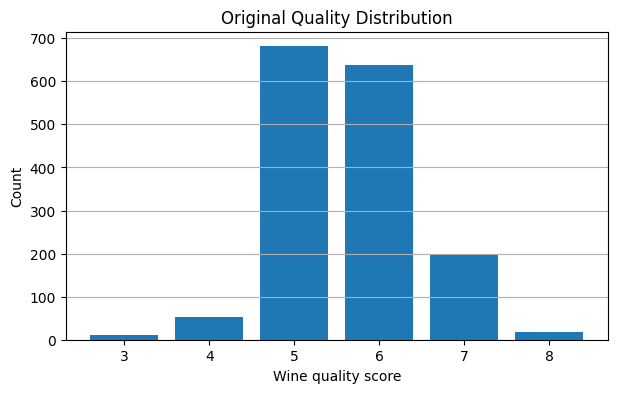

In [6]:

# ============================================================
# quality 분포 확인
# ============================================================

# "quality"는 와인 품질 점수입니다.
# value_counts()는 값별 데이터 개수를 계산합니다.
# sort_index()는 quality 점수 순서대로 정렬합니다.
quality_counts = df["quality"].value_counts().sort_index()

# 원본 품질 점수의 분포를 출력합니다.
# 어떤 점수에 데이터가 몰려 있는지 확인할 수 있습니다.
print("원본 quality 분포:")
print(quality_counts)

# 그래프 크기를 지정합니다.
plt.figure(figsize=(7, 4))

# quality 점수별 데이터 개수를 막대그래프로 표시합니다.
# x축: quality 점수
# y축: 해당 점수의 데이터 개수
plt.bar(quality_counts.index.astype(str), quality_counts.values)

# x축 이름을 설정합니다.
plt.xlabel("Wine quality score")

# y축 이름을 설정합니다.
plt.ylabel("Count")

# 그래프 제목을 설정합니다.
plt.title("Original Quality Distribution")

# y축 기준 격자선을 표시하여 막대 높이를 보기 쉽게 합니다.
plt.grid(axis="y")

# 그래프를 출력합니다.
plt.show()


In [7]:

# ============================================================
# quality 점수를 3개 등급으로 변환
# ============================================================

# 원본 quality는 3~8 사이의 숫자 점수입니다.
# 실무 분류 문제로 만들기 위해 품질 점수를 3개 클래스로 변환합니다.
# 0: low, 1: medium, 2: high
def convert_quality_to_class(q):
    # quality가 4 이하이면 저품질(low)로 분류합니다.
    # 낮은 품질 점수는 데이터 수가 적을 수 있으므로 클래스 불균형을 주의해야 합니다.
    if q <= 4:
        return 0

    # quality가 5 또는 6이면 중간품질(medium)로 분류합니다.
    # 실제 Wine Quality 데이터에서는 5와 6에 데이터가 많이 몰려 있습니다.
    elif q <= 6:
        return 1

    # quality가 7 이상이면 고품질(high)로 분류합니다.
    else:
        return 2

# apply()는 quality 컬럼의 각 값에 convert_quality_to_class 함수를 적용합니다.
# 결과는 새 컬럼 quality_class에 저장합니다.
df["quality_class"] = df["quality"].apply(convert_quality_to_class)

# 변환된 클래스별 데이터 개수를 확인합니다.
# 클래스 분포가 지나치게 불균형하면 accuracy만으로 모델을 평가하면 안 됩니다.
print("변환된 quality_class 분포:")
print(df["quality_class"].value_counts().sort_index())

# 원본 quality와 변환된 quality_class가 어떻게 대응되는지 일부 행을 확인합니다.
df[["quality", "quality_class"]].head(10)


변환된 quality_class 분포:
quality_class
0      63
1    1319
2     217
Name: count, dtype: int64


,quality,quality_class
0,5,1
1,5,1
2,5,1
3,6,1
4,5,1
5,5,1
6,5,1
7,7,2
8,7,2
9,5,1


## 3단계. 입력 변수와 목표 변수 분리

입력 변수 `X`에는 와인의 화학적 특성을 넣습니다.

정답 변수 `y`에는 새로 만든 `quality_class`를 넣습니다.


In [8]:

# ============================================================
# 입력 변수 X와 목표 변수 y 분리
# ============================================================

# 머신러닝 모델은 입력 데이터 X와 정답 데이터 y를 분리해서 사용합니다.
# quality는 원본 점수이고, quality_class는 변환된 정답 클래스입니다.
# 두 컬럼 모두 정답과 직접 관련되어 있으므로 입력 변수에서 제외해야 합니다.
# 만약 quality를 입력에 포함하면 정답 정보를 모델에 알려주는 데이터 누수가 발생합니다.
X = df.drop(columns=["quality", "quality_class"])

# y에는 모델이 예측해야 할 정답인 quality_class를 넣습니다.
y = df["quality_class"]

# 입력 변수 이름을 리스트로 저장합니다.
# 나중에 어떤 변수가 사용되었는지 확인하거나 중요도를 해석할 때 필요합니다.
feature_names = X.columns.tolist()

# 입력 변수 개수를 출력합니다.
print("입력 변수 개수:", X.shape[1])

# 입력 변수 목록을 출력합니다.
print("입력 변수 목록:", feature_names)

# 목표 클래스 종류를 출력합니다.
print("목표 클래스:", sorted(y.unique()))


입력 변수 개수: 11
입력 변수 목록: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
목표 클래스: [np.int64(0), np.int64(1), np.int64(2)]


In [9]:

# ============================================================
# 학습 데이터와 테스트 데이터 분리
# ============================================================

# train_test_split()은 전체 데이터를 학습 데이터와 테스트 데이터로 나눕니다.
# 학습 데이터는 모델을 학습시키는 데 사용하고,
# 테스트 데이터는 학습이 끝난 뒤 모델 성능을 평가하는 데 사용합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # 입력 변수 전체
    y,                  # 정답 클래스
    test_size=0.2,      # 전체 데이터의 20%를 테스트 데이터로 사용
    random_state=SEED,  # 항상 같은 방식으로 분리되도록 랜덤 시드 고정
    stratify=y          # 클래스 비율을 학습/테스트 데이터에 비슷하게 유지
)

# 분리된 데이터 크기를 확인합니다.
# X_train과 y_train의 행 수가 같아야 합니다.
# X_test와 y_test의 행 수도 같아야 합니다.
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (1279, 11)
X_test: (320, 11)
y_train: (1279,)
y_test: (320,)


In [10]:

# ============================================================
# 데이터 표준화
# ============================================================

# StandardScaler는 각 입력 변수의 평균을 0, 표준편차를 1로 변환합니다.
# 공식:
# z = (x - 평균) / 표준편차
#
# 차원 축소 알고리즘에서 표준화가 중요한 이유:
# - PCA는 분산이 큰 방향을 찾기 때문에 값의 단위가 큰 변수가 과도하게 영향력을 가질 수 있습니다.
# - LDA도 거리와 분산 구조를 사용하므로 변수 스케일 차이가 결과에 영향을 줄 수 있습니다.
# - t-SNE, UMAP도 거리 기반 이웃 관계를 사용하므로 표준화가 중요합니다.
scaler = StandardScaler()

# 학습 데이터에는 fit_transform()을 사용합니다.
# fit 단계: 학습 데이터의 평균과 표준편차를 계산합니다.
# transform 단계: 계산된 평균과 표준편차를 이용해 학습 데이터를 변환합니다.
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 데이터에는 transform()만 사용합니다.
# 테스트 데이터에서 평균과 표준편차를 새로 계산하면 테스트 데이터 정보가 전처리에 섞이는 데이터 누수가 발생합니다.
X_test_scaled = scaler.transform(X_test)

# 표준화가 잘 되었는지 평균과 표준편차를 확인합니다.
print("표준화 후 학습 데이터 평균:", round(X_train_scaled.mean(), 4))
print("표준화 후 학습 데이터 표준편차:", round(X_train_scaled.std(), 4))


표준화 후 학습 데이터 평균: -0.0
표준화 후 학습 데이터 표준편차: 1.0


## 4단계. 원본 데이터 기준 모델 학습

차원 축소 전 원본 데이터로 모델을 학습합니다.

이 결과는 차원 축소 후 모델 성능과 비교하기 위한 기준입니다.


In [11]:

# ============================================================
# 원본 데이터 기준 Random Forest 모델 학습
# ============================================================

# RandomForestClassifier는 여러 개의 Decision Tree를 학습한 뒤,
# 그 결과를 투표 방식으로 결합하는 앙상블 분류 모델입니다.
# 여기서는 차원 축소 전 원본 데이터 기준 성능을 확인하기 위해 사용합니다.
baseline_rf = RandomForestClassifier(
    n_estimators=300,        # 만들 의사결정나무 개수입니다. 많을수록 안정적이지만 학습 시간이 늘어납니다.
    random_state=SEED,       # 결과 재현성을 위한 랜덤 시드입니다.
    class_weight="balanced"  # 클래스별 데이터 수가 다를 때 소수 클래스에 더 큰 가중치를 줍니다.
)

# fit()은 모델을 학습시키는 함수입니다.
# X_train_scaled: 표준화된 학습 입력 데이터
# y_train: 학습 정답 데이터
baseline_rf.fit(X_train_scaled, y_train)

# predict()는 학습된 모델로 테스트 데이터의 클래스를 예측합니다.
baseline_pred = baseline_rf.predict(X_test_scaled)

# accuracy_score()는 전체 테스트 데이터 중 예측이 맞은 비율을 계산합니다.
baseline_acc = accuracy_score(y_test, baseline_pred)

print("원본 데이터 기준 Random Forest 정확도:", round(baseline_acc, 4))
print()

# classification_report()는 클래스별 precision, recall, f1-score를 출력합니다.
# 클래스 불균형이 있는 경우 accuracy만 보는 것보다 이 지표들을 함께 보는 것이 좋습니다.
print(classification_report(y_test, baseline_pred, target_names=["low", "medium", "high"]))


원본 데이터 기준 Random Forest 정확도: 0.8781

              precision    recall  f1-score   support

         low       0.00      0.00      0.00        13
      medium       0.90      0.96      0.93       264
        high       0.75      0.63      0.68        43

    accuracy                           0.88       320
   macro avg       0.55      0.53      0.54       320
weighted avg       0.84      0.88      0.86       320



In [12]:

# ============================================================
# 원본 데이터 기준 Logistic Regression 모델 학습
# ============================================================

# LogisticRegression은 선형 분류 모델입니다.
# 데이터가 선형 경계로 어느 정도 분리되는지 확인할 때 기준 모델로 사용하기 좋습니다.
baseline_lr = LogisticRegression(
    max_iter=2000,           # 최적화 반복 횟수입니다. 작으면 수렴하지 않을 수 있어 넉넉하게 지정합니다.
    random_state=SEED,       # 결과 재현성을 위한 랜덤 시드입니다.
    class_weight="balanced"  # 클래스 불균형을 보정합니다.
)

# 표준화된 원본 데이터로 Logistic Regression을 학습합니다.
baseline_lr.fit(X_train_scaled, y_train)

# 테스트 데이터를 예측합니다.
baseline_lr_pred = baseline_lr.predict(X_test_scaled)

# 정확도를 계산합니다.
baseline_lr_acc = accuracy_score(y_test, baseline_lr_pred)

print("원본 데이터 기준 Logistic Regression 정확도:", round(baseline_lr_acc, 4))
print()

# 클래스별 성능 지표를 출력합니다.
print(classification_report(y_test, baseline_lr_pred, target_names=["low", "medium", "high"]))


원본 데이터 기준 Logistic Regression 정확도: 0.5875

              precision    recall  f1-score   support

         low       0.15      0.77      0.25        13
      medium       0.96      0.54      0.69       264
        high       0.34      0.81      0.48        43

    accuracy                           0.59       320
   macro avg       0.48      0.71      0.47       320
weighted avg       0.84      0.59      0.65       320



# 5단계. PCA 적용

PCA는 정답 라벨을 사용하지 않는 비지도학습 차원 축소 알고리즘입니다.

PCA는 데이터의 분산이 큰 방향을 찾아 새로운 축을 만듭니다.


In [13]:

# ============================================================
# PCA 2차원 변환
# ============================================================

# PCA(Principal Component Analysis)는 주성분 분석입니다.
# 정답 라벨 y를 사용하지 않고, 입력 데이터 X의 분산 구조만 사용합니다.
# 즉, PCA는 비지도학습 기반 차원 축소 알고리즘입니다.

# n_components=2는 원본 11차원 입력 데이터를 2개의 주성분으로 줄이겠다는 의미입니다.
# 2차원으로 줄이면 산점도 그래프로 시각화할 수 있습니다.
pca_2d = PCA(n_components=2, random_state=SEED)

# fit_transform()은 두 가지 작업을 동시에 수행합니다.
# 1. fit: 학습 데이터에서 분산이 가장 큰 방향, 즉 주성분 축을 찾습니다.
# 2. transform: 원본 데이터를 찾은 주성분 축 위로 투영하여 2차원 값으로 변환합니다.
#
# PCA의 핵심:
# - PC1: 데이터 분산을 가장 많이 설명하는 첫 번째 축
# - PC2: PC1과 직교하면서 그 다음으로 분산을 많이 설명하는 두 번째 축
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

# 테스트 데이터는 transform()만 사용합니다.
# 학습 데이터에서 찾은 PCA 축을 기준으로 테스트 데이터를 2차원으로 변환합니다.
# 테스트 데이터에 fit_transform()을 사용하면 데이터 누수가 발생할 수 있습니다.
X_test_pca_2d = pca_2d.transform(X_test_scaled)

# PCA 적용 전후의 데이터 차원을 확인합니다.
print("PCA 적용 전:", X_train_scaled.shape)
print("PCA 2D 적용 후:", X_train_pca_2d.shape)

# explained_variance_ratio_는 각 주성분이 원본 데이터의 정보를 얼마나 설명하는지 나타냅니다.
# 예를 들어 PC1 설명 분산 비율이 0.28이면 PC1 하나가 전체 정보의 약 28%를 설명한다는 의미입니다.
print("PC1 설명 분산 비율:", round(pca_2d.explained_variance_ratio_[0], 4))
print("PC2 설명 분산 비율:", round(pca_2d.explained_variance_ratio_[1], 4))

# PC1과 PC2가 함께 설명하는 정보 비율입니다.
# 이 값이 낮으면 2차원으로 줄일 때 정보 손실이 크다는 뜻입니다.
print("누적 설명 분산 비율:", round(pca_2d.explained_variance_ratio_.sum(), 4))


PCA 적용 전: (1279, 11)
PCA 2D 적용 후: (1279, 2)
PC1 설명 분산 비율: 0.2806
PC2 설명 분산 비율: 0.1755
누적 설명 분산 비율: 0.4561


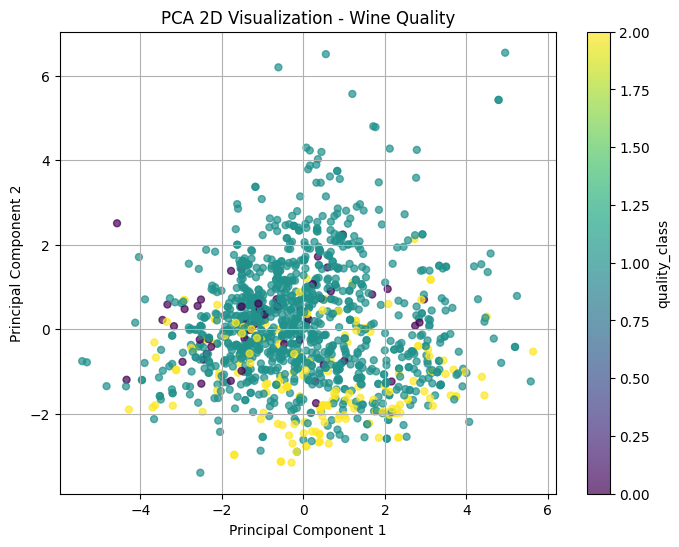

In [14]:

# ============================================================
# PCA 2차원 시각화
# ============================================================

# PCA로 축소된 2차원 데이터는 x축 PC1, y축 PC2로 시각화할 수 있습니다.
# 이 그래프를 통해 클래스가 어느 정도 분리되는지 눈으로 확인할 수 있습니다.
plt.figure(figsize=(8, 6))

# plt.scatter()는 산점도를 그리는 함수입니다.
# X_train_pca_2d[:, 0]은 첫 번째 주성분 PC1 값입니다.
# X_train_pca_2d[:, 1]은 두 번째 주성분 PC2 값입니다.
# c=y_train은 정답 클래스에 따라 점 색상을 다르게 표시합니다.
scatter = plt.scatter(
    X_train_pca_2d[:, 0],
    X_train_pca_2d[:, 1],
    c=y_train,
    cmap="viridis",
    alpha=0.7,
    s=25
)

# 색상 막대를 추가하여 색이 어떤 클래스를 의미하는지 표시합니다.
plt.colorbar(scatter, label="quality_class")

# x축 이름을 설정합니다.
plt.xlabel("Principal Component 1")

# y축 이름을 설정합니다.
plt.ylabel("Principal Component 2")

# 그래프 제목을 설정합니다.
plt.title("PCA 2D Visualization - Wine Quality")

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


In [15]:

# ============================================================
# PCA 누적 설명 분산 확인
# ============================================================

# PCA에서는 주성분 개수를 몇 개로 정할지가 중요합니다.
# 너무 적게 선택하면 정보 손실이 크고,
# 너무 많이 선택하면 차원 축소 효과가 작아집니다.

# n_components를 입력 변수 개수만큼 설정합니다.
# 이 데이터는 입력 변수가 11개이므로 최대 11개의 주성분을 만들 수 있습니다.
pca_full = PCA(n_components=X_train_scaled.shape[1], random_state=SEED)

# fit()은 PCA 주성분 축을 학습합니다.
# 여기서는 변환보다 각 주성분의 설명 분산 비율을 확인하는 것이 목적입니다.
pca_full.fit(X_train_scaled)

# explained_variance_ratio_는 주성분별 설명 분산 비율입니다.
# np.cumsum()은 누적합을 계산합니다.
# 예: [0.28, 0.17, 0.14] → [0.28, 0.45, 0.59]
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 주성분 개수별 누적 설명 분산 비율을 표로 정리합니다.
# 이 표를 보고 몇 개의 주성분을 사용할지 결정할 수 있습니다.
pca_variance_df = pd.DataFrame({
    "component_count": np.arange(1, len(cumulative_variance) + 1),
    "cumulative_explained_variance": cumulative_variance
})

pca_variance_df


,component_count,cumulative_explained_variance
0,1,0.280557
1,2,0.456066
2,3,0.598114
3,4,0.705398
4,5,0.794076
5,6,0.854157
6,7,0.908541
7,8,0.949095
8,9,0.978798
9,10,0.994845


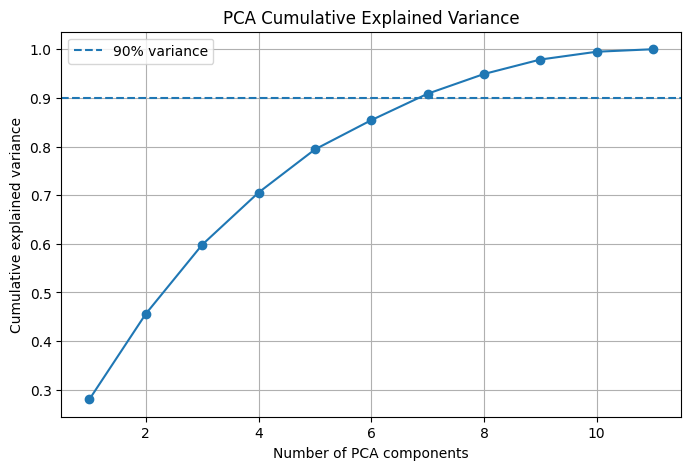

In [16]:

# ============================================================
# PCA 누적 설명 분산 그래프
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# x축: 주성분 개수
# y축: 누적 설명 분산 비율
# 이 그래프는 차원을 몇 개로 줄일지 결정하는 데 사용합니다.
plt.plot(
    pca_variance_df["component_count"],
    pca_variance_df["cumulative_explained_variance"],
    marker="o"
)

# 누적 설명 분산 90% 기준선을 표시합니다.
# 실무에서는 보통 80~95% 정도의 정보를 유지하는 주성분 개수를 선택합니다.
plt.axhline(y=0.90, linestyle="--", label="90% variance")

# x축 이름입니다.
plt.xlabel("Number of PCA components")

# y축 이름입니다.
plt.ylabel("Cumulative explained variance")

# 그래프 제목입니다.
plt.title("PCA Cumulative Explained Variance")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


In [17]:

# ============================================================
# PCA 차원 축소 후 분류 모델 학습
# ============================================================

# PCA를 실제 모델 학습 전처리로 사용합니다.
# 여기서는 원본 11차원 데이터를 6차원으로 줄입니다.
# 차원을 줄이면 계산량이 줄고, 일부 노이즈가 제거될 수 있습니다.
pca_model = PCA(n_components=6, random_state=SEED)

# 학습 데이터에 대해 PCA 축을 찾고 6차원으로 변환합니다.
X_train_pca = pca_model.fit_transform(X_train_scaled)

# 테스트 데이터는 학습 데이터에서 찾은 PCA 축을 기준으로 6차원으로 변환합니다.
X_test_pca = pca_model.transform(X_test_scaled)

# 6개 주성분이 원본 데이터 정보를 얼마나 보존하는지 확인합니다.
print("PCA 6차원 누적 설명 분산:", round(pca_model.explained_variance_ratio_.sum(), 4))

# PCA로 축소된 데이터에 Random Forest를 학습합니다.
# 원본 데이터 성능과 비교하여 차원 축소가 성능에 어떤 영향을 주는지 확인합니다.
rf_pca = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    class_weight="balanced"
)

# PCA 변환된 학습 데이터로 모델을 학습합니다.
rf_pca.fit(X_train_pca, y_train)

# PCA 변환된 테스트 데이터로 예측합니다.
pca_pred = rf_pca.predict(X_test_pca)

# 정확도를 계산합니다.
pca_acc = accuracy_score(y_test, pca_pred)

print("PCA 6차원 Random Forest 정확도:", round(pca_acc, 4))
print()

# 클래스별 성능을 출력합니다.
print(classification_report(y_test, pca_pred, target_names=["low", "medium", "high"]))


PCA 6차원 누적 설명 분산: 0.8542
PCA 6차원 Random Forest 정확도: 0.8625

              precision    recall  f1-score   support

         low       0.00      0.00      0.00        13
      medium       0.88      0.97      0.92       264
        high       0.70      0.49      0.58        43

    accuracy                           0.86       320
   macro avg       0.53      0.48      0.50       320
weighted avg       0.82      0.86      0.84       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 6단계. LDA 적용

LDA는 정답 라벨을 사용하는 지도학습 기반 차원 축소 알고리즘입니다.

PCA가 분산이 큰 방향을 찾는다면, LDA는 클래스가 잘 구분되는 방향을 찾습니다.

현재 클래스는 3개이므로 LDA의 최대 차원은 `3 - 1 = 2`입니다.


In [18]:

# ============================================================
# LDA 2차원 변환
# ============================================================

# LDA(Linear Discriminant Analysis)는 선형 판별 분석입니다.
# PCA와 달리 정답 라벨 y를 사용합니다.
#
# PCA의 목적:
# - 데이터의 분산이 큰 방향을 찾음
#
# LDA의 목적:
# - 클래스들이 가장 잘 분리되는 방향을 찾음
#
# 현재 클래스는 low, medium, high 총 3개입니다.
# LDA가 만들 수 있는 최대 차원은 클래스 수 - 1입니다.
# 따라서 3개 클래스에서는 최대 2차원까지 축소할 수 있습니다.
lda_2d = LinearDiscriminantAnalysis(n_components=2)

# LDA는 지도학습 기반 차원 축소이므로 fit_transform()에 X뿐 아니라 y_train도 함께 넣습니다.
# y_train을 사용하여 클래스 간 분산은 크게, 클래스 내부 분산은 작게 만드는 축을 찾습니다.
X_train_lda_2d = lda_2d.fit_transform(X_train_scaled, y_train)

# 테스트 데이터는 학습 데이터에서 찾은 LDA 축을 기준으로 변환합니다.
X_test_lda_2d = lda_2d.transform(X_test_scaled)

# LDA 적용 전후 차원을 확인합니다.
print("LDA 적용 전:", X_train_scaled.shape)
print("LDA 적용 후:", X_train_lda_2d.shape)


LDA 적용 전: (1279, 11)
LDA 적용 후: (1279, 2)


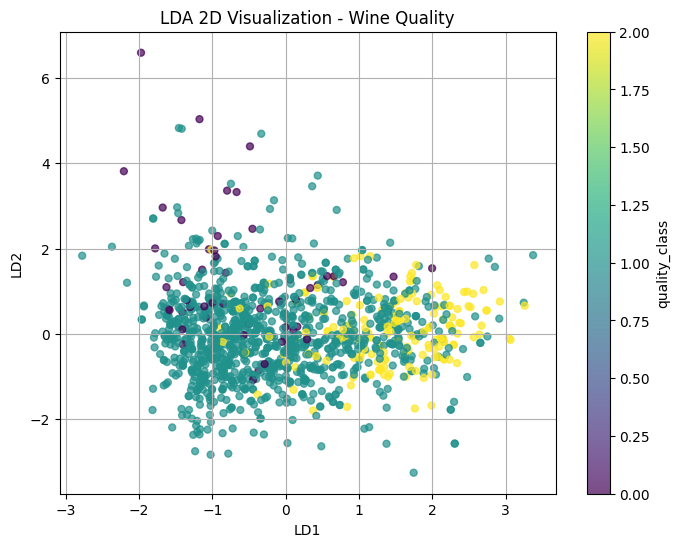

In [19]:

# ============================================================
# LDA 2차원 시각화
# ============================================================

# LDA는 클래스 구분이 잘 되는 방향을 찾으므로,
# PCA보다 클래스 분리 시각화가 더 명확할 수 있습니다.
plt.figure(figsize=(8, 6))

# x축은 첫 번째 선형 판별 축 LD1입니다.
# y축은 두 번째 선형 판별 축 LD2입니다.
# 점 색상은 실제 품질 클래스입니다.
scatter = plt.scatter(
    X_train_lda_2d[:, 0],
    X_train_lda_2d[:, 1],
    c=y_train,
    cmap="viridis",
    alpha=0.7,
    s=25
)

# 색상과 클래스의 대응 관계를 표시합니다.
plt.colorbar(scatter, label="quality_class")

# x축 이름입니다.
plt.xlabel("LD1")

# y축 이름입니다.
plt.ylabel("LD2")

# 그래프 제목입니다.
plt.title("LDA 2D Visualization - Wine Quality")

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


In [20]:

# ============================================================
# LDA 차원 축소 후 분류 모델 학습
# ============================================================

# LDA로 변환된 2차원 데이터를 사용해 Random Forest 모델을 학습합니다.
# 원본 11차원 데이터를 2차원으로 줄였기 때문에 학습 데이터 크기가 작아졌습니다.
rf_lda = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    class_weight="balanced"
)

# LDA 변환된 학습 데이터로 모델을 학습합니다.
rf_lda.fit(X_train_lda_2d, y_train)

# LDA 변환된 테스트 데이터로 예측합니다.
lda_pred = rf_lda.predict(X_test_lda_2d)

# 정확도를 계산합니다.
lda_acc = accuracy_score(y_test, lda_pred)

print("LDA 2차원 Random Forest 정확도:", round(lda_acc, 4))
print()

# 클래스별 상세 평가 결과를 출력합니다.
print(classification_report(y_test, lda_pred, target_names=["low", "medium", "high"]))


LDA 2차원 Random Forest 정확도: 0.8625

              precision    recall  f1-score   support

         low       0.00      0.00      0.00        13
      medium       0.89      0.95      0.92       264
        high       0.73      0.56      0.63        43

    accuracy                           0.86       320
   macro avg       0.54      0.50      0.52       320
weighted avg       0.83      0.86      0.84       320



# 7단계. t-SNE 적용

t-SNE는 고차원 데이터를 2차원으로 시각화할 때 자주 사용하는 비선형 차원 축소 알고리즘입니다.

주의할 점:

- 주로 시각화 목적입니다.
- 일반적인 sklearn t-SNE는 새 테스트 데이터에 대한 `transform()` 사용이 어렵습니다.
- 모델 학습 전처리보다는 데이터 탐색용으로 많이 사용합니다.


In [21]:

# ============================================================
# t-SNE 2차원 변환
# ============================================================

# t-SNE는 t-distributed Stochastic Neighbor Embedding의 약자입니다.
# 고차원 공간에서 가까운 데이터끼리의 관계를 저차원에서도 유지하려고 합니다.
#
# t-SNE의 주요 목적:
# - 분류 모델 학습용 전처리보다는 시각화
# - 고차원 데이터의 군집 구조 확인
# - 비슷한 샘플들이 실제로 가까이 모이는지 확인

# 시각화 목적이므로 전체 데이터를 사용합니다.
# 단, 실제 모델 평가용 전처리에서는 학습/테스트 분리를 먼저 고려해야 합니다.
X_scaled_all = scaler.fit_transform(X)

# TSNE 객체를 생성합니다.
tsne = TSNE(
    n_components=2,      # 2차원 좌표로 축소합니다.
    perplexity=30,       # 각 점이 고려하는 이웃 수의 개념입니다. 보통 5~50 사이를 많이 사용합니다.
    learning_rate="auto",# 학습률을 자동 설정합니다.
    init="pca",          # 초기 배치를 PCA 결과로 시작하여 안정적인 결과를 얻습니다.
    random_state=SEED    # 재현성을 위한 랜덤 시드입니다.
)

# fit_transform()으로 전체 데이터를 2차원으로 변환합니다.
# t-SNE는 PCA처럼 일반적인 transform() 사용이 어렵기 때문에 주로 전체 데이터 시각화에 사용합니다.
X_tsne = tsne.fit_transform(X_scaled_all)

# 변환 전후 차원을 확인합니다.
print("t-SNE 적용 전:", X_scaled_all.shape)
print("t-SNE 적용 후:", X_tsne.shape)


t-SNE 적용 전: (1599, 11)
t-SNE 적용 후: (1599, 2)


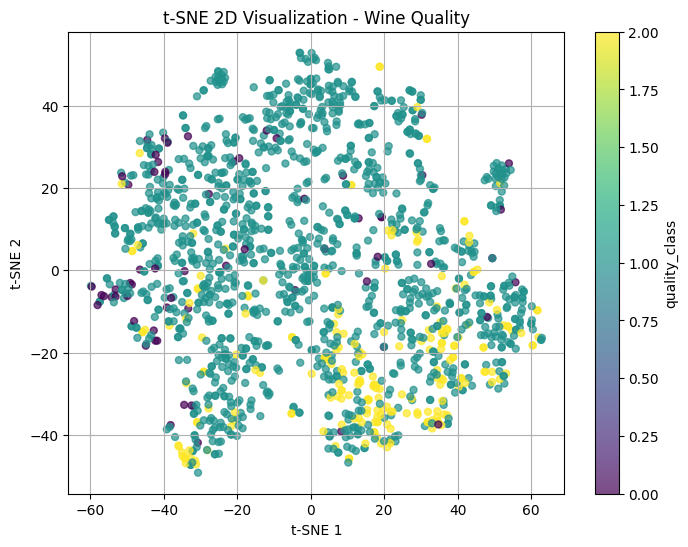

In [22]:

# ============================================================
# t-SNE 시각화
# ============================================================

# t-SNE 결과는 2차원 좌표입니다.
# x축과 y축 자체에 물리적인 의미가 있는 것은 아닙니다.
# 중요한 것은 점들 사이의 가까움과 군집 구조입니다.
plt.figure(figsize=(8, 6))

# X_tsne[:, 0]은 t-SNE가 만든 첫 번째 2차원 좌표입니다.
# X_tsne[:, 1]은 두 번째 좌표입니다.
# c=y는 실제 품질 클래스에 따라 색상을 다르게 표시합니다.
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="viridis",
    alpha=0.7,
    s=25
)

# 색상 막대를 표시합니다.
plt.colorbar(scatter, label="quality_class")

# x축 이름입니다.
plt.xlabel("t-SNE 1")

# y축 이름입니다.
plt.ylabel("t-SNE 2")

# 그래프 제목입니다.
plt.title("t-SNE 2D Visualization - Wine Quality")

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


# 8단계. UMAP 적용

UMAP은 t-SNE와 유사한 비선형 차원 축소 알고리즘입니다.

실무에서는 고차원 임베딩 데이터 시각화, 대용량 데이터 시각화 등에 자주 사용됩니다.


In [23]:

# ============================================================
# UMAP 2차원 변환
# ============================================================

# UMAP은 Uniform Manifold Approximation and Projection의 약자입니다.
# t-SNE처럼 비선형 차원 축소와 시각화에 많이 사용됩니다.
#
# UMAP의 특징:
# - 고차원 데이터의 이웃 관계를 보존하려고 함
# - t-SNE보다 빠른 경우가 많음
# - 2차원 시각화뿐 아니라 임베딩 축소에도 사용 가능

# UMAP 객체를 생성합니다.
umap_model = umap.UMAP(
    n_components=2,    # 2차원으로 축소합니다.
    n_neighbors=15,    # 각 데이터가 주변 이웃을 몇 개까지 고려할지 정합니다.
                       # 값이 작으면 지역 구조를 더 강조하고, 값이 크면 전체 구조를 더 반영합니다.
    min_dist=0.1,      # 저차원 공간에서 점들이 얼마나 가까이 모일 수 있는지를 조절합니다.
                       # 값이 작으면 군집이 더 조밀하게 모일 수 있습니다.
    random_state=SEED  # 재현성을 위한 랜덤 시드입니다.
)

# fit_transform()으로 전체 데이터를 2차원 UMAP 좌표로 변환합니다.
# X_scaled_all은 표준화된 전체 입력 데이터입니다.
X_umap = umap_model.fit_transform(X_scaled_all)

# 변환 전후 차원을 확인합니다.
print("UMAP 적용 전:", X_scaled_all.shape)
print("UMAP 적용 후:", X_umap.shape)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 적용 전: (1599, 11)
UMAP 적용 후: (1599, 2)


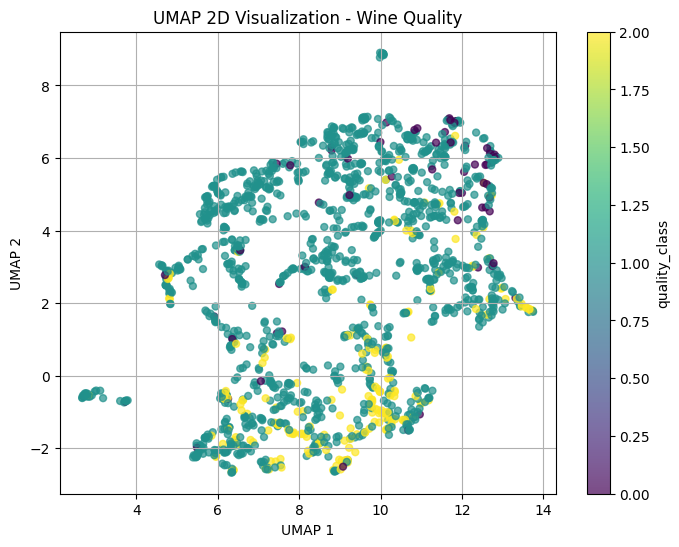

In [24]:

# ============================================================
# UMAP 시각화
# ============================================================

# UMAP 결과를 2차원 산점도로 표시합니다.
# t-SNE와 마찬가지로 x축, y축 자체의 의미보다는 점들의 배치와 군집 구조를 해석합니다.
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_umap[:, 0],      # UMAP 첫 번째 좌표
    X_umap[:, 1],      # UMAP 두 번째 좌표
    c=y,               # 실제 품질 클래스로 색상 지정
    cmap="viridis",
    alpha=0.7,
    s=25
)

# 색상 막대를 표시합니다.
plt.colorbar(scatter, label="quality_class")

# x축 이름입니다.
plt.xlabel("UMAP 1")

# y축 이름입니다.
plt.ylabel("UMAP 2")

# 그래프 제목입니다.
plt.title("UMAP 2D Visualization - Wine Quality")

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


# 9단계. Autoencoder 적용

Autoencoder는 딥러닝 기반 차원 축소 방법입니다.

입력 데이터를 압축한 뒤 다시 복원하도록 학습합니다.

```text
입력 데이터
↓
Encoder
↓
잠재 벡터
↓
Decoder
↓
복원 데이터
```

여기서는 11차원 입력 데이터를 2차원 잠재 벡터로 압축합니다.


In [25]:

# ============================================================
# Autoencoder 데이터 준비
# ============================================================

# Autoencoder는 입력 데이터를 압축한 뒤 다시 원본처럼 복원하도록 학습하는 신경망입니다.
# 일반 분류 모델은 X와 y가 다르지만,
# Autoencoder는 입력 X 자체를 정답으로 사용합니다.
#
# 즉, 학습 목표는 다음과 같습니다.
# 입력 X → Encoder로 압축 → Decoder로 복원 → 원본 X와 최대한 비슷하게 만들기

# numpy 배열인 X_train_scaled를 PyTorch Tensor로 변환합니다.
# dtype=torch.float32는 신경망 학습에 적합한 32비트 실수형입니다.
X_train_ae = torch.tensor(X_train_scaled, dtype=torch.float32)

# 테스트 데이터도 Tensor로 변환합니다.
X_test_ae = torch.tensor(X_test_scaled, dtype=torch.float32)

# TensorDataset은 입력과 정답을 하나로 묶어줍니다.
# Autoencoder에서는 입력과 정답이 모두 같은 X입니다.
train_dataset = TensorDataset(X_train_ae, X_train_ae)
test_dataset = TensorDataset(X_test_ae, X_test_ae)

# DataLoader는 데이터를 batch 단위로 나누어 모델에 공급합니다.
# batch_size=64는 한 번에 64개 샘플씩 학습한다는 의미입니다.
# shuffle=True는 매 epoch마다 학습 데이터 순서를 섞어 학습 안정성을 높입니다.
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

# 테스트 데이터는 평가용이므로 순서를 섞을 필요가 없습니다.
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# Autoencoder 학습에 사용할 Tensor 크기를 확인합니다.
print("Autoencoder 학습 데이터:", X_train_ae.shape)
print("Autoencoder 테스트 데이터:", X_test_ae.shape)


Autoencoder 학습 데이터: torch.Size([1279, 11])
Autoencoder 테스트 데이터: torch.Size([320, 11])


In [26]:

# ============================================================
# Autoencoder 모델 정의
# ============================================================

# Autoencoder는 크게 Encoder와 Decoder로 구성됩니다.
#
# Encoder:
# - 원본 입력 데이터를 더 작은 차원의 잠재 벡터로 압축합니다.
#
# Decoder:
# - 압축된 잠재 벡터를 다시 원본 입력 형태로 복원합니다.
#
# 여기서는 11차원 와인 특성 데이터를 2차원 잠재 벡터로 압축합니다.
class WineAutoencoder(nn.Module):
    def __init__(self, input_dim):
        # nn.Module 부모 클래스의 초기화 함수를 실행합니다.
        super(WineAutoencoder, self).__init__()

        # ----------------------------------------------------
        # Encoder 정의
        # ----------------------------------------------------
        # Encoder는 차원을 점점 줄입니다.
        # input_dim → 8 → 4 → 2
        # 마지막 2차원 출력이 차원 축소된 표현입니다.
        self.encoder = nn.Sequential(
            # 첫 번째 선형 계층입니다.
            # input_dim은 입력 변수 개수입니다. 이 데이터에서는 11입니다.
            # 11차원 데이터를 8차원으로 변환합니다.
            nn.Linear(input_dim, 8),

            # ReLU 활성화 함수입니다.
            # 선형 변환만 반복하면 복잡한 비선형 구조를 학습할 수 없으므로 활성화 함수를 사용합니다.
            nn.ReLU(),

            # 두 번째 선형 계층입니다.
            # 8차원 데이터를 4차원으로 줄입니다.
            nn.Linear(8, 4),

            # 다시 ReLU를 적용하여 비선형 표현력을 추가합니다.
            nn.ReLU(),

            # 마지막 Encoder 계층입니다.
            # 4차원 데이터를 최종 2차원 잠재 벡터로 압축합니다.
            # 이 2차원 값이 Autoencoder 방식의 차원 축소 결과입니다.
            nn.Linear(4, 2)
        )

        # ----------------------------------------------------
        # Decoder 정의
        # ----------------------------------------------------
        # Decoder는 Encoder와 반대로 차원을 점점 늘립니다.
        # 2 → 4 → 8 → input_dim
        # 최종 출력은 원본 입력 데이터와 같은 11차원입니다.
        self.decoder = nn.Sequential(
            # 2차원 잠재 벡터를 4차원으로 확장합니다.
            nn.Linear(2, 4),
            nn.ReLU(),

            # 4차원 데이터를 8차원으로 확장합니다.
            nn.Linear(4, 8),
            nn.ReLU(),

            # 8차원 데이터를 원본 입력 차원으로 복원합니다.
            nn.Linear(8, input_dim)
        )

    def forward(self, x):
        # 입력 x를 Encoder에 넣어 2차원 잠재 벡터 z로 압축합니다.
        z = self.encoder(x)

        # 잠재 벡터 z를 Decoder에 넣어 원본 차원으로 복원합니다.
        reconstructed = self.decoder(z)

        # 복원 결과와 잠재 벡터를 함께 반환합니다.
        # reconstructed: 원본과 비교할 복원 데이터
        # z: 차원 축소된 2차원 표현
        return reconstructed, z

# 입력 변수 개수입니다.
# Wine Quality 데이터에서는 11개의 화학적 특성이 입력 변수입니다.
input_dim = X_train_scaled.shape[1]

# Autoencoder 모델 객체를 생성하고 CPU 또는 GPU 장치로 이동합니다.
ae_model = WineAutoencoder(input_dim).to(device)

# 모델 구조를 출력합니다.
print(ae_model)


WineAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=11, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=11, bias=True)
  )
)


In [27]:

# ============================================================
# Autoencoder 학습 설정
# ============================================================

# MSELoss는 평균제곱오차 손실 함수입니다.
# Autoencoder에서는 원본 입력과 복원 결과가 얼마나 다른지 계산합니다.
#
# MSE가 작을수록:
# - 복원 결과가 원본과 비슷함
# - Encoder가 원본 정보를 잘 압축했다는 의미
criterion = nn.MSELoss()

# Adam은 딥러닝에서 자주 사용하는 최적화 알고리즘입니다.
# optimizer는 손실을 줄이도록 모델의 가중치를 업데이트합니다.
optimizer = optim.Adam(
    ae_model.parameters(),  # 학습할 모델 파라미터
    lr=0.001               # 학습률입니다. 값이 너무 크면 불안정하고, 너무 작으면 학습이 느립니다.
)

# 전체 학습 반복 횟수입니다.
# epoch는 전체 학습 데이터를 한 번 모두 학습하는 단위입니다.
epochs = 150

# epoch별 학습 손실과 테스트 손실을 저장할 리스트입니다.
train_losses = []
test_losses = []

print("Autoencoder 학습 설정 완료")


Autoencoder 학습 설정 완료


In [28]:

# ============================================================
# Autoencoder 학습 루프
# ============================================================

# epochs만큼 전체 데이터를 반복 학습합니다.
for epoch in range(epochs):
    # --------------------------------------------------------
    # 1. 학습 모드 설정
    # --------------------------------------------------------

    # train()은 모델을 학습 모드로 전환합니다.
    # Dropout, BatchNorm 같은 계층이 있을 경우 학습 방식으로 동작합니다.
    ae_model.train()

    # 한 epoch 동안의 학습 손실 합계를 저장할 변수입니다.
    train_loss_sum = 0.0

    # train_loader에서 batch 단위로 데이터를 꺼냅니다.
    # batch_X: 입력 데이터
    # batch_y: 복원 목표 데이터
    # Autoencoder에서는 batch_X와 batch_y가 같은 데이터입니다.
    for batch_X, batch_y in train_loader:
        # 데이터를 현재 장치로 이동합니다.
        # GPU가 있으면 GPU로, 없으면 CPU로 이동합니다.
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # 이전 batch에서 계산된 gradient를 초기화합니다.
        # PyTorch는 gradient를 누적하므로 매 batch마다 반드시 초기화해야 합니다.
        optimizer.zero_grad()

        # Autoencoder에 입력 데이터를 넣습니다.
        # reconstructed: Decoder가 복원한 결과
        # z: Encoder가 만든 2차원 잠재 벡터
        reconstructed, z = ae_model(batch_X)

        # 원본 데이터 batch_y와 복원 데이터 reconstructed의 차이를 계산합니다.
        # 이 손실이 작아질수록 복원 성능이 좋아집니다.
        loss = criterion(reconstructed, batch_y)

        # 역전파를 수행하여 각 가중치가 손실에 미치는 영향을 계산합니다.
        loss.backward()

        # optimizer가 계산된 gradient를 사용하여 모델 가중치를 업데이트합니다.
        optimizer.step()

        # 현재 batch의 손실값을 누적합니다.
        train_loss_sum += loss.item()

    # 한 epoch의 평균 학습 손실을 계산합니다.
    train_loss = train_loss_sum / len(train_loader)

    # --------------------------------------------------------
    # 2. 평가 모드 설정
    # --------------------------------------------------------

    # eval()은 모델을 평가 모드로 전환합니다.
    # 평가 시에는 가중치를 업데이트하지 않습니다.
    ae_model.eval()

    # 테스트 손실 합계입니다.
    test_loss_sum = 0.0

    # torch.no_grad()는 gradient 계산을 비활성화합니다.
    # 평가 단계에서는 gradient가 필요 없으므로 메모리 사용량과 계산량을 줄일 수 있습니다.
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            # 테스트 batch를 장치로 이동합니다.
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            # 복원 결과와 잠재 벡터를 계산합니다.
            reconstructed, z = ae_model(batch_X)

            # 테스트 손실을 계산합니다.
            loss = criterion(reconstructed, batch_y)

            # 테스트 손실을 누적합니다.
            test_loss_sum += loss.item()

    # 평균 테스트 손실을 계산합니다.
    test_loss = test_loss_sum / len(test_loader)

    # 그래프 출력을 위해 손실값을 리스트에 저장합니다.
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # 15 epoch마다 학습 진행 상황을 출력합니다.
    # 손실이 계속 감소하면 학습이 잘 진행되고 있다는 의미입니다.
    if (epoch + 1) % 15 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.6f} "
            f"Test Loss: {test_loss:.6f}"
        )


Epoch [15/150] Train Loss: 0.931064 Test Loss: 1.058330
Epoch [30/150] Train Loss: 0.812716 Test Loss: 0.973542
Epoch [45/150] Train Loss: 0.749111 Test Loss: 0.897310
Epoch [60/150] Train Loss: 0.721639 Test Loss: 0.854207
Epoch [75/150] Train Loss: 0.641570 Test Loss: 0.750429
Epoch [90/150] Train Loss: 0.541719 Test Loss: 0.616122
Epoch [105/150] Train Loss: 0.493261 Test Loss: 0.539040
Epoch [120/150] Train Loss: 0.482999 Test Loss: 0.526242
Epoch [135/150] Train Loss: 0.477637 Test Loss: 0.519154
Epoch [150/150] Train Loss: 0.473983 Test Loss: 0.514622


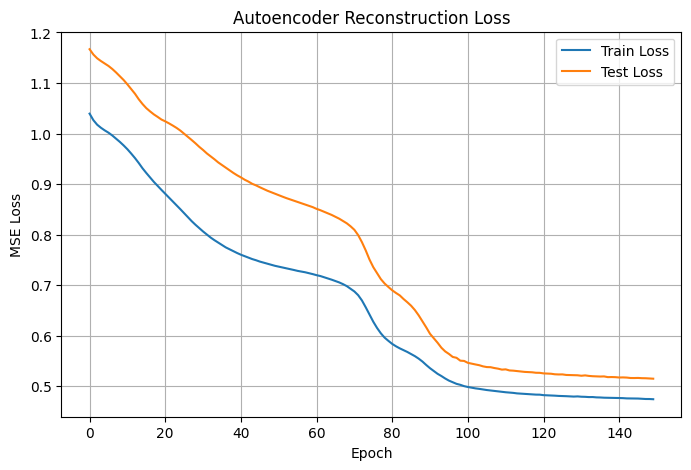

In [29]:

# ============================================================
# Autoencoder 학습 손실 그래프
# ============================================================

# 학습 과정에서 손실이 어떻게 변하는지 확인합니다.
# Train Loss와 Test Loss가 함께 감소하면 학습이 안정적으로 진행된 것입니다.
# Train Loss만 낮고 Test Loss가 높으면 과적합 가능성이 있습니다.
plt.figure(figsize=(8, 5))

# 학습 손실 그래프입니다.
plt.plot(train_losses, label="Train Loss")

# 테스트 손실 그래프입니다.
plt.plot(test_losses, label="Test Loss")

# x축은 epoch입니다.
plt.xlabel("Epoch")

# y축은 MSE 손실값입니다.
plt.ylabel("MSE Loss")

# 그래프 제목입니다.
plt.title("Autoencoder Reconstruction Loss")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


In [30]:

# ============================================================
# Autoencoder 잠재 벡터 추출
# ============================================================

# 전체 데이터를 표준화합니다.
# 주의:
# - 여기서는 전체 데이터 시각화를 위한 목적입니다.
# - 실제 모델 평가에서는 학습 데이터로 fit한 scaler를 테스트 데이터에 transform하는 방식이 더 엄격합니다.
X_all_scaled = scaler.fit_transform(X)

# 전체 데이터를 PyTorch Tensor로 변환하고 현재 장치로 이동합니다.
X_all_tensor = torch.tensor(X_all_scaled, dtype=torch.float32).to(device)

# 모델을 평가 모드로 전환합니다.
ae_model.eval()

# gradient 계산 없이 전체 데이터의 잠재 벡터를 추출합니다.
with torch.no_grad():
    # reconstructed_all: 전체 데이터의 복원 결과
    # latent_all: Encoder가 만든 2차원 잠재 벡터
    reconstructed_all, latent_all = ae_model(X_all_tensor)

# latent_all은 PyTorch Tensor이므로 numpy 배열로 변환합니다.
# cpu()는 GPU에 있는 Tensor를 CPU로 옮기는 함수입니다.
# numpy()는 Tensor를 numpy 배열로 변환하는 함수입니다.
X_ae_2d = latent_all.cpu().numpy()

# Autoencoder 적용 전후 차원을 확인합니다.
print("Autoencoder 적용 전:", X_all_scaled.shape)
print("Autoencoder 2차원 잠재 벡터:", X_ae_2d.shape)


Autoencoder 적용 전: (1599, 11)
Autoencoder 2차원 잠재 벡터: (1599, 2)


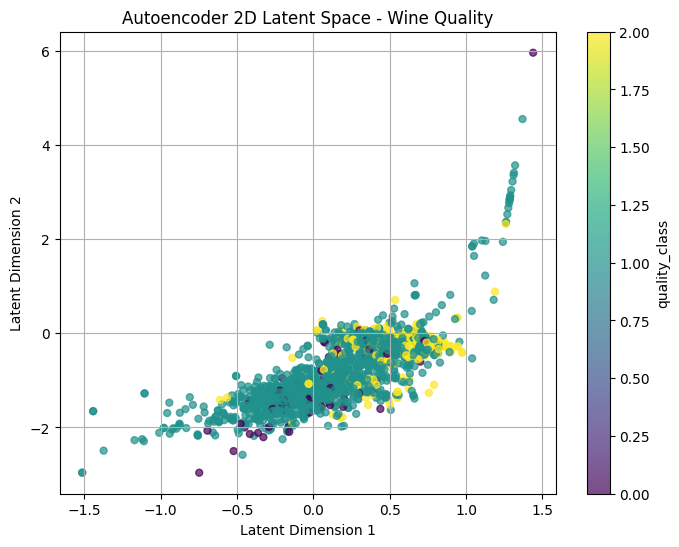

In [31]:

# ============================================================
# Autoencoder 2차원 잠재 공간 시각화
# ============================================================

# Autoencoder의 Encoder가 만든 2차원 잠재 벡터를 시각화합니다.
# 이 그래프는 신경망이 데이터를 어떤 방식으로 압축했는지 확인하는 데 사용합니다.
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_ae_2d[:, 0],      # 잠재 벡터의 첫 번째 차원
    X_ae_2d[:, 1],      # 잠재 벡터의 두 번째 차원
    c=y,                # 실제 품질 클래스로 색상을 지정
    cmap="viridis",
    alpha=0.7,
    s=25
)

# 색상 막대를 표시합니다.
plt.colorbar(scatter, label="quality_class")

# x축 이름입니다.
plt.xlabel("Latent Dimension 1")

# y축 이름입니다.
plt.ylabel("Latent Dimension 2")

# 그래프 제목입니다.
plt.title("Autoencoder 2D Latent Space - Wine Quality")

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


In [32]:

# ============================================================
# Autoencoder 2차원 데이터로 분류 모델 학습
# ============================================================

# 학습 데이터와 테스트 데이터를 Tensor로 변환합니다.
# 이미 표준화된 데이터를 사용합니다.
X_train_tensor_all = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_tensor_all = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

# 모델을 평가 모드로 전환합니다.
ae_model.eval()

# Autoencoder의 Encoder를 이용해 학습/테스트 데이터를 2차원 잠재 벡터로 변환합니다.
with torch.no_grad():
    # _는 복원 결과를 사용하지 않겠다는 의미입니다.
    # X_train_ae_latent는 학습 데이터의 2차원 잠재 벡터입니다.
    _, X_train_ae_latent = ae_model(X_train_tensor_all)

    # X_test_ae_latent는 테스트 데이터의 2차원 잠재 벡터입니다.
    _, X_test_ae_latent = ae_model(X_test_tensor_all)

# PyTorch Tensor를 numpy 배열로 변환합니다.
X_train_ae_latent = X_train_ae_latent.cpu().numpy()
X_test_ae_latent = X_test_ae_latent.cpu().numpy()

# Autoencoder로 축소된 2차원 데이터를 사용하여 Random Forest를 학습합니다.
# 이 과정은 "딥러닝 기반 차원 축소 + 머신러닝 분류 모델" 구조입니다.
rf_ae = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    class_weight="balanced"
)

# 2차원 잠재 벡터로 모델을 학습합니다.
rf_ae.fit(X_train_ae_latent, y_train)

# 테스트 잠재 벡터로 품질 클래스를 예측합니다.
ae_pred = rf_ae.predict(X_test_ae_latent)

# 정확도를 계산합니다.
ae_acc = accuracy_score(y_test, ae_pred)

print("Autoencoder 2차원 Random Forest 정확도:", round(ae_acc, 4))
print()

# 클래스별 성능을 출력합니다.
print(classification_report(y_test, ae_pred, target_names=["low", "medium", "high"]))


Autoencoder 2차원 Random Forest 정확도: 0.85

              precision    recall  f1-score   support

         low       0.00      0.00      0.00        13
      medium       0.87      0.96      0.91       264
        high       0.69      0.42      0.52        43

    accuracy                           0.85       320
   macro avg       0.52      0.46      0.48       320
weighted avg       0.81      0.85      0.82       320



# 10단계. 전체 성능 비교

원본 데이터와 차원 축소 후 데이터를 사용한 분류 정확도를 비교합니다.

t-SNE와 UMAP은 주로 시각화용이므로 성능 비교표에는 포함하지 않았습니다.


In [33]:

# ============================================================
# 결과 비교표 생성
# ============================================================

# 원본 데이터와 차원 축소 후 데이터의 분류 성능을 비교합니다.
# t-SNE와 UMAP은 주로 시각화용이므로 여기서는 성능 비교표에 포함하지 않습니다.
results = pd.DataFrame({
    "method": [
        "Original RF",                   # 원본 11차원 + Random Forest
        "Original Logistic Regression",  # 원본 11차원 + Logistic Regression
        "PCA 6D + RF",                   # PCA 6차원 + Random Forest
        "LDA 2D + RF",                   # LDA 2차원 + Random Forest
        "Autoencoder 2D + RF"            # Autoencoder 2차원 + Random Forest
    ],
    "dimension": [
        X_train_scaled.shape[1],          # 원본 입력 차원 수
        X_train_scaled.shape[1],          # 원본 입력 차원 수
        6,                                # PCA 축소 후 차원 수
        2,                                # LDA 축소 후 차원 수
        2                                 # Autoencoder 잠재 벡터 차원 수
    ],
    "accuracy": [
        baseline_acc,                     # 원본 Random Forest 정확도
        baseline_lr_acc,                  # 원본 Logistic Regression 정확도
        pca_acc,                          # PCA 후 정확도
        lda_acc,                          # LDA 후 정확도
        ae_acc                            # Autoencoder 후 정확도
    ]
})

# 정확도를 소수점 4자리로 반올림합니다.
results["accuracy"] = results["accuracy"].round(4)

# 결과표를 출력합니다.
results


,method,dimension,accuracy
0,Original RF,11,0.8781
1,Original Logistic Regression,11,0.5875
2,PCA 6D + RF,6,0.8625
3,LDA 2D + RF,2,0.8625
4,Autoencoder 2D + RF,2,0.8500


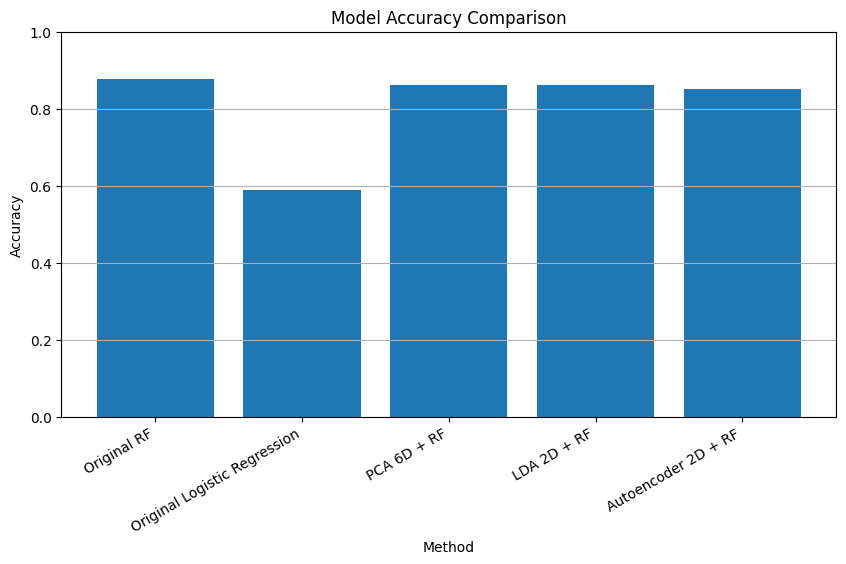

In [34]:

# ============================================================
# 결과 비교 그래프
# ============================================================

# 결과 비교표의 accuracy 값을 막대그래프로 시각화합니다.
plt.figure(figsize=(10, 5))

# x축은 방법, y축은 정확도입니다.
plt.bar(results["method"], results["accuracy"])

# 정확도는 0~1 범위이므로 y축 범위를 0~1로 설정합니다.
plt.ylim(0, 1.0)

# x축 이름입니다.
plt.xlabel("Method")

# y축 이름입니다.
plt.ylabel("Accuracy")

# 그래프 제목입니다.
plt.title("Model Accuracy Comparison")

# x축 라벨이 길기 때문에 30도 회전시켜 겹치지 않게 합니다.
plt.xticks(rotation=30, ha="right")

# y축 기준 격자선을 표시합니다.
plt.grid(axis="y")

# 그래프를 출력합니다.
plt.show()


# 11단계. 실무 해석

## PCA

PCA는 정답 라벨을 사용하지 않고 데이터의 분산 구조를 기준으로 차원을 줄입니다.  
입력 변수가 많고, 변수 간 상관관계가 높거나, 학습 속도를 줄이고 싶을 때 유용합니다.

## LDA

LDA는 정답 라벨을 사용하여 클래스가 잘 구분되는 방향으로 차원을 줄입니다.  
분류 문제에서 차원 축소를 수행할 때 유용합니다.

## t-SNE

t-SNE는 고차원 데이터의 군집 구조를 2차원으로 확인하는 데 적합합니다.  
모델 학습용 전처리보다는 탐색적 데이터 분석에 적합합니다.

## UMAP

UMAP은 t-SNE와 유사하지만 일반적으로 빠르고 대용량 데이터에 더 적합한 경우가 많습니다.

## Autoencoder

Autoencoder는 신경망을 사용하여 데이터를 압축합니다.  
선형 차원 축소로 표현하기 어려운 비선형 구조를 학습할 수 있습니다.

## 최종 정리

| 목적 | 추천 방법 |
|---|---|
| 기본 차원 축소 | PCA |
| 라벨 기반 차원 축소 | LDA |
| 고차원 데이터 시각화 | t-SNE, UMAP |
| 비선형 압축 | Autoencoder |
| 기준 성능 확인 | Random Forest |


# 12단계. 추가 실습 과제

## 과제 1. PCA 주성분 수 변경

아래 값을 바꾸면서 정확도를 비교하시오.

```python
n_components=2
n_components=4
n_components=6
n_components=8
n_components=10
```

## 과제 2. Random Forest 파라미터 변경

```python
n_estimators=100
n_estimators=300
n_estimators=500
```

```python
max_depth=3
max_depth=5
max_depth=None
```

## 과제 3. UMAP 파라미터 변경

```python
n_neighbors=5
n_neighbors=15
n_neighbors=30
```

```python
min_dist=0.01
min_dist=0.1
min_dist=0.5
```

## 과제 4. Autoencoder 잠재 차원 변경

잠재 차원을 2에서 3 또는 4로 변경한 뒤 성능을 비교하시오.

## 과제 5. 이진 분류로 변경

현재 3개 클래스를 다음과 같이 2개 클래스로 변경하시오.

```text
quality <= 5 → low
quality >= 6 → high
```


## 12단계 추가 실습 과제 풀이 코드

아래 코드는 12단계의 과제 1~5를 바로 실행할 수 있도록 완성한 코드입니다.  
기존 1~11단계에서 만든 `X`, `y`, `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test`, `SEED`, `device` 변수를 그대로 사용합니다.

### 과제 1. PCA 주성분 수 변경 후 정확도 비교

`n_components` 값을 2, 4, 6, 8, 10으로 바꾸어 PCA 차원 축소 후 Random Forest 정확도를 비교합니다.

In [ ]:
# ============================================================
# 과제 1. PCA 주성분 수 변경 후 정확도 비교
# ============================================================

# PCA 주성분 개수 후보를 리스트로 저장합니다.
# 원본 입력 변수는 11개이므로 2, 4, 6, 8, 10개 주성분을 비교할 수 있습니다.
pca_component_list = [2, 4, 6, 8, 10]

# 각 주성분 개수별 실험 결과를 저장할 빈 리스트를 만듭니다.
# 반복문이 한 번 실행될 때마다 정확도 결과가 이 리스트에 추가됩니다.
pca_practice_results = []

# 주성분 개수 후보를 하나씩 꺼내어 PCA와 분류 모델을 반복 학습합니다.
for n_comp in pca_component_list:
    # --------------------------------------------------------
    # 1. PCA 객체 생성
    # --------------------------------------------------------
    # n_components는 원본 데이터를 몇 개의 주성분으로 줄일지 정하는 값입니다.
    # random_state는 같은 결과가 나오도록 난수 시드를 고정하는 값입니다.
    pca_temp = PCA(n_components=n_comp, random_state=SEED)
    
    # --------------------------------------------------------
    # 2. 학습 데이터 PCA 변환
    # --------------------------------------------------------
    # fit_transform()은 학습 데이터에서 PCA 축을 찾고, 그 축으로 데이터를 변환합니다.
    # 학습 데이터에서는 PCA 기준을 새로 학습해야 하므로 fit_transform()을 사용합니다.
    X_train_pca_temp = pca_temp.fit_transform(X_train_scaled)
    
    # --------------------------------------------------------
    # 3. 테스트 데이터 PCA 변환
    # --------------------------------------------------------
    # 테스트 데이터에는 fit_transform()을 사용하면 안 됩니다.
    # 테스트 데이터는 학습 데이터에서 찾은 PCA 축을 그대로 사용해야 공정한 평가가 됩니다.
    X_test_pca_temp = pca_temp.transform(X_test_scaled)
    
    # --------------------------------------------------------
    # 4. Random Forest 모델 생성
    # --------------------------------------------------------
    # PCA로 축소된 데이터의 분류 성능을 확인하기 위해 Random Forest를 사용합니다.
    # class_weight="balanced"는 클래스 불균형의 영향을 줄이기 위한 설정입니다.
    rf_temp = RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        class_weight="balanced"
    )
    
    # --------------------------------------------------------
    # 5. 모델 학습
    # --------------------------------------------------------
    # PCA로 축소된 학습 데이터를 사용해 Random Forest를 학습합니다.
    rf_temp.fit(X_train_pca_temp, y_train)
    
    # --------------------------------------------------------
    # 6. 테스트 데이터 예측
    # --------------------------------------------------------
    # 학습된 모델로 PCA 변환된 테스트 데이터를 예측합니다.
    y_pred_pca_temp = rf_temp.predict(X_test_pca_temp)
    
    # --------------------------------------------------------
    # 7. 정확도 계산
    # --------------------------------------------------------
    # accuracy_score는 전체 테스트 데이터 중 맞춘 비율을 계산합니다.
    acc_temp = accuracy_score(y_test, y_pred_pca_temp)
    
    # --------------------------------------------------------
    # 8. 설명 분산 비율 계산
    # --------------------------------------------------------
    # explained_variance_ratio_는 각 주성분이 원본 데이터 정보를 얼마나 설명하는지 나타냅니다.
    # sum()을 사용하면 선택한 주성분들이 설명하는 전체 정보량을 계산할 수 있습니다.
    explained_variance_sum = pca_temp.explained_variance_ratio_.sum()
    
    # --------------------------------------------------------
    # 9. 결과 저장
    # --------------------------------------------------------
    # 결과를 딕셔너리 형태로 저장한 뒤 리스트에 추가합니다.
    pca_practice_results.append({
        "n_components": n_comp,
        "explained_variance_sum": explained_variance_sum,
        "accuracy": acc_temp
    })

# 반복 실험 결과를 pandas DataFrame으로 변환합니다.
# DataFrame으로 만들면 표 형태로 보기 쉽고 그래프도 쉽게 그릴 수 있습니다.
pca_practice_df = pd.DataFrame(pca_practice_results)

# 결과표를 출력합니다.
pca_practice_df

In [ ]:
# ============================================================
# 과제 1 결과 시각화
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# x축은 PCA 주성분 개수, y축은 정확도입니다.
plt.plot(
    pca_practice_df["n_components"],
    pca_practice_df["accuracy"],
    marker="o",
    label="Accuracy"
)

# 같은 그래프에 누적 설명 분산 비율도 함께 표시합니다.
# 정확도와 설명 분산 비율은 모두 0~1 범위이므로 한 그래프에서 비교할 수 있습니다.
plt.plot(
    pca_practice_df["n_components"],
    pca_practice_df["explained_variance_sum"],
    marker="s",
    label="Explained Variance Sum"
)

# x축 이름을 설정합니다.
plt.xlabel("Number of PCA Components")

# y축 이름을 설정합니다.
plt.ylabel("Score")

# 그래프 제목을 설정합니다.
plt.title("Practice 1: PCA Components vs Accuracy")

# 범례를 표시합니다.
plt.legend()

# 격자를 표시하여 값 비교를 쉽게 합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

### 과제 2. Random Forest 파라미터 변경

`n_estimators`와 `max_depth` 조합을 바꾸어 원본 표준화 데이터 기준 정확도를 비교합니다.

In [ ]:
# ============================================================
# 과제 2. Random Forest 파라미터 변경 후 정확도 비교
# ============================================================

# Random Forest에서 사용할 트리 개수 후보입니다.
# n_estimators가 클수록 여러 나무의 평균 효과가 커져 안정적일 수 있지만 학습 시간이 증가합니다.
n_estimators_list = [100, 300, 500]

# Random Forest에서 사용할 최대 깊이 후보입니다.
# max_depth가 작으면 모델이 단순해지고, None이면 깊이에 제한을 두지 않습니다.
max_depth_list = [3, 5, None]

# 실험 결과를 저장할 빈 리스트입니다.
rf_practice_results = []

# 트리 개수와 최대 깊이의 모든 조합을 실험합니다.
for n_est in n_estimators_list:
    # max_depth 후보를 하나씩 반복합니다.
    for depth in max_depth_list:
        # ----------------------------------------------------
        # 1. Random Forest 모델 생성
        # ----------------------------------------------------
        # n_estimators: 사용할 의사결정나무 개수입니다.
        # max_depth: 각 나무가 얼마나 깊게 분기할 수 있는지 정합니다.
        # class_weight="balanced": 클래스 불균형을 보정합니다.
        rf_temp = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            random_state=SEED,
            class_weight="balanced"
        )
        
        # ----------------------------------------------------
        # 2. 모델 학습
        # ----------------------------------------------------
        # 원본 표준화 학습 데이터 11개 특성을 모두 사용합니다.
        rf_temp.fit(X_train_scaled, y_train)
        
        # ----------------------------------------------------
        # 3. 테스트 데이터 예측
        # ----------------------------------------------------
        # 학습된 Random Forest로 테스트 데이터를 예측합니다.
        y_pred_rf_temp = rf_temp.predict(X_test_scaled)
        
        # ----------------------------------------------------
        # 4. 정확도 계산
        # ----------------------------------------------------
        # 실제 정답과 예측값을 비교하여 정확도를 계산합니다.
        acc_temp = accuracy_score(y_test, y_pred_rf_temp)
        
        # ----------------------------------------------------
        # 5. 결과 저장
        # ----------------------------------------------------
        # max_depth가 None인 경우 표에서는 문자열 "None"으로 표시되도록 저장합니다.
        rf_practice_results.append({
            "n_estimators": n_est,
            "max_depth": "None" if depth is None else depth,
            "accuracy": acc_temp
        })

# 결과 리스트를 DataFrame으로 변환합니다.
rf_practice_df = pd.DataFrame(rf_practice_results)

# 정확도가 높은 순서로 정렬합니다.
rf_practice_df = rf_practice_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

# 결과표를 출력합니다.
rf_practice_df

In [ ]:
# ============================================================
# 과제 2 최고 성능 조합 확인
# ============================================================

# DataFrame의 첫 번째 행은 정확도가 가장 높은 조합입니다.
best_rf_row = rf_practice_df.iloc[0]

# 최고 성능 파라미터를 출력합니다.
print("Random Forest 최고 성능 조합")
print("n_estimators:", best_rf_row["n_estimators"])
print("max_depth:", best_rf_row["max_depth"])
print("accuracy:", best_rf_row["accuracy"])

# 피벗 테이블을 만들어 n_estimators와 max_depth 조합별 정확도를 보기 쉽게 정리합니다.
rf_pivot = rf_practice_df.pivot(
    index="max_depth",
    columns="n_estimators",
    values="accuracy"
)

# 피벗 테이블을 출력합니다.
rf_pivot

### 과제 3. UMAP 파라미터 변경

`n_neighbors`와 `min_dist` 조합을 바꾸어 UMAP 2차원 변환 결과를 시각화하고, 축소된 데이터 기준 분류 정확도를 비교합니다.

In [ ]:
# ============================================================
# 과제 3. UMAP 파라미터 변경 후 정확도 비교
# ============================================================

# UMAP에서 사용할 이웃 개수 후보입니다.
# 값이 작으면 가까운 국소 구조를 더 중시하고, 값이 크면 전체 구조를 더 중시합니다.
umap_neighbors_list = [5, 15, 30]

# UMAP에서 사용할 최소 거리 후보입니다.
# 값이 작으면 점들이 더 촘촘하게 모이고, 값이 크면 점들이 더 넓게 퍼집니다.
umap_min_dist_list = [0.01, 0.1, 0.5]

# UMAP 실험 결과를 저장할 리스트입니다.
umap_practice_results = []

# 시각화를 위해 그래프 번호를 관리할 변수입니다.
plot_index = 1

# 전체 그래프 크기를 설정합니다.
plt.figure(figsize=(15, 12))

# n_neighbors와 min_dist의 모든 조합을 실험합니다.
for n_neighbors in umap_neighbors_list:
    # min_dist 후보를 하나씩 반복합니다.
    for min_dist in umap_min_dist_list:
        # ----------------------------------------------------
        # 1. UMAP 객체 생성
        # ----------------------------------------------------
        # n_components=2는 데이터를 2차원으로 줄이겠다는 뜻입니다.
        # n_neighbors는 이웃 데이터 개수를 의미합니다.
        # min_dist는 저차원 공간에서 점 사이 최소 거리를 조절합니다.
        umap_temp = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=SEED
        )
        
        # ----------------------------------------------------
        # 2. 학습 데이터 UMAP 변환
        # ----------------------------------------------------
        # fit_transform()은 학습 데이터에서 UMAP 구조를 학습하고 2차원으로 변환합니다.
        X_train_umap_temp = umap_temp.fit_transform(X_train_scaled)
        
        # ----------------------------------------------------
        # 3. 테스트 데이터 UMAP 변환
        # ----------------------------------------------------
        # umap-learn은 transform()을 지원하므로 학습된 UMAP 구조를 테스트 데이터에 적용할 수 있습니다.
        X_test_umap_temp = umap_temp.transform(X_test_scaled)
        
        # ----------------------------------------------------
        # 4. 분류 모델 생성 및 학습
        # ----------------------------------------------------
        # 2차원 UMAP 결과를 사용하여 Random Forest 분류기를 학습합니다.
        rf_umap_temp = RandomForestClassifier(
            n_estimators=300,
            random_state=SEED,
            class_weight="balanced"
        )
        
        # UMAP으로 축소된 학습 데이터로 모델을 학습합니다.
        rf_umap_temp.fit(X_train_umap_temp, y_train)
        
        # ----------------------------------------------------
        # 5. 테스트 데이터 예측 및 정확도 계산
        # ----------------------------------------------------
        # UMAP으로 축소된 테스트 데이터에 대해 예측합니다.
        y_pred_umap_temp = rf_umap_temp.predict(X_test_umap_temp)
        
        # 정확도를 계산합니다.
        acc_temp = accuracy_score(y_test, y_pred_umap_temp)
        
        # ----------------------------------------------------
        # 6. 결과 저장
        # ----------------------------------------------------
        # 파라미터 조합과 정확도를 저장합니다.
        umap_practice_results.append({
            "n_neighbors": n_neighbors,
            "min_dist": min_dist,
            "accuracy": acc_temp
        })
        
        # ----------------------------------------------------
        # 7. UMAP 시각화
        # ----------------------------------------------------
        # 3행 3열 그래프 중 현재 위치를 지정합니다.
        plt.subplot(3, 3, plot_index)
        
        # UMAP 2차원 결과를 산점도로 표시합니다.
        plt.scatter(
            X_train_umap_temp[:, 0],
            X_train_umap_temp[:, 1],
            c=y_train,
            cmap="viridis",
            alpha=0.7,
            s=20
        )
        
        # 각 그래프의 제목에 파라미터와 정확도를 표시합니다.
        plt.title(f"neighbors={n_neighbors}, min_dist={min_dist}\nacc={acc_temp:.4f}")
        
        # x축 눈금과 y축 눈금은 생략하여 그래프를 간결하게 만듭니다.
        plt.xticks([])
        plt.yticks([])
        
        # 다음 subplot 위치로 이동합니다.
        plot_index += 1

# 전체 그래프 제목을 설정합니다.
plt.suptitle("Practice 3: UMAP Parameter Comparison", fontsize=16)

# 그래프 간격을 자동 조정합니다.
plt.tight_layout()

# 그래프를 출력합니다.
plt.show()

# 결과를 DataFrame으로 변환합니다.
umap_practice_df = pd.DataFrame(umap_practice_results)

# 정확도 기준 내림차순으로 정렬합니다.
umap_practice_df = umap_practice_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

# 결과표를 출력합니다.
umap_practice_df

### 과제 4. Autoencoder 잠재 차원 변경

잠재 차원을 2, 3, 4로 바꾸어 Autoencoder 압축 결과를 비교합니다.  
각 잠재 벡터를 Random Forest에 입력하여 분류 정확도를 확인합니다.

In [ ]:
# ============================================================
# 과제 4. Autoencoder 잠재 차원 변경 후 성능 비교
# ============================================================

# Autoencoder 잠재 차원 후보입니다.
# latent_dim이 작을수록 강하게 압축하고, 클수록 더 많은 정보를 보존할 수 있습니다.
ae_latent_dim_list = [2, 3, 4]

# Autoencoder 실험 결과를 저장할 리스트입니다.
ae_practice_results = []

# 입력 변수 개수를 저장합니다.
# Wine Quality 데이터에서는 입력 특성이 11개입니다.
input_dim = X_train_scaled.shape[1]

# Autoencoder를 반복 실험하기 위한 클래스입니다.
# latent_dim을 외부에서 받아 2차원, 3차원, 4차원 구조를 만들 수 있게 합니다.
class PracticeAutoencoder(nn.Module):
    # __init__은 모델 객체가 생성될 때 실행되는 초기화 함수입니다.
    def __init__(self, input_dim, latent_dim):
        # 부모 클래스 nn.Module의 초기화 함수를 실행합니다.
        super(PracticeAutoencoder, self).__init__()
        
        # Encoder는 원본 입력을 작은 잠재 벡터로 압축합니다.
        self.encoder = nn.Sequential(
            # 첫 번째 선형 계층: 입력 차원에서 16차원으로 변환합니다.
            nn.Linear(input_dim, 16),
            
            # ReLU는 음수는 0으로 만들고 양수는 그대로 통과시키는 활성화 함수입니다.
            nn.ReLU(),
            
            # 두 번째 선형 계층: 16차원에서 8차원으로 변환합니다.
            nn.Linear(16, 8),
            
            # 비선형성을 추가하기 위해 ReLU를 다시 사용합니다.
            nn.ReLU(),
            
            # 마지막 Encoder 계층: 8차원에서 latent_dim 차원으로 압축합니다.
            nn.Linear(8, latent_dim)
        )
        
        # Decoder는 잠재 벡터를 다시 원본 입력 차원으로 복원합니다.
        self.decoder = nn.Sequential(
            # latent_dim 차원에서 8차원으로 확장합니다.
            nn.Linear(latent_dim, 8),
            
            # ReLU 활성화 함수를 적용합니다.
            nn.ReLU(),
            
            # 8차원에서 16차원으로 확장합니다.
            nn.Linear(8, 16),
            
            # ReLU 활성화 함수를 적용합니다.
            nn.ReLU(),
            
            # 16차원에서 원본 입력 차원으로 복원합니다.
            nn.Linear(16, input_dim)
        )
    
    # forward는 모델에 데이터가 들어왔을 때 실행되는 순전파 함수입니다.
    def forward(self, x):
        # 입력 데이터를 Encoder에 넣어 잠재 벡터로 압축합니다.
        z = self.encoder(x)
        
        # 잠재 벡터를 Decoder에 넣어 원본 차원으로 복원합니다.
        reconstructed = self.decoder(z)
        
        # 복원 결과를 반환합니다.
        return reconstructed

# 학습 데이터와 테스트 데이터를 PyTorch Tensor로 변환합니다.
# float32는 신경망 학습에서 일반적으로 사용하는 실수 자료형입니다.
X_train_tensor_practice = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_tensor_practice = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

# 잠재 차원 후보를 하나씩 실험합니다.
for latent_dim in ae_latent_dim_list:
    # --------------------------------------------------------
    # 1. Autoencoder 모델 생성
    # --------------------------------------------------------
    # 입력 차원과 잠재 차원을 지정하여 Autoencoder를 생성합니다.
    ae_temp = PracticeAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
    
    # --------------------------------------------------------
    # 2. 손실 함수와 최적화 알고리즘 설정
    # --------------------------------------------------------
    # MSELoss는 원본 입력과 복원 결과 사이의 평균제곱오차를 계산합니다.
    criterion_temp = nn.MSELoss()
    
    # Adam은 신경망 가중치를 자동으로 조정하는 최적화 알고리즘입니다.
    optimizer_temp = optim.Adam(ae_temp.parameters(), lr=0.001)
    
    # --------------------------------------------------------
    # 3. 학습 반복 횟수 설정
    # --------------------------------------------------------
    # 실습 시간을 고려하여 80 epoch만 학습합니다.
    # 더 안정적인 결과가 필요하면 100~300으로 늘릴 수 있습니다.
    practice_epochs = 80
    
    # --------------------------------------------------------
    # 4. Autoencoder 학습
    # --------------------------------------------------------
    for epoch in range(practice_epochs):
        # 모델을 학습 모드로 전환합니다.
        ae_temp.train()
        
        # 이전 단계에서 계산된 gradient를 초기화합니다.
        optimizer_temp.zero_grad()
        
        # 학습 데이터를 Autoencoder에 입력하여 복원 결과를 얻습니다.
        reconstructed = ae_temp(X_train_tensor_practice)
        
        # 원본 입력과 복원 결과 사이의 MSE 손실을 계산합니다.
        loss = criterion_temp(reconstructed, X_train_tensor_practice)
        
        # 손실을 기준으로 역전파를 수행하여 gradient를 계산합니다.
        loss.backward()
        
        # 계산된 gradient를 사용해 모델 파라미터를 업데이트합니다.
        optimizer_temp.step()
    
    # --------------------------------------------------------
    # 5. 잠재 벡터 추출
    # --------------------------------------------------------
    # 평가 모드로 전환합니다.
    ae_temp.eval()
    
    # gradient 계산 없이 Encoder 결과만 추출합니다.
    with torch.no_grad():
        # 학습 데이터의 잠재 벡터를 추출하고 CPU numpy 배열로 변환합니다.
        X_train_ae_temp = ae_temp.encoder(X_train_tensor_practice).cpu().numpy()
        
        # 테스트 데이터의 잠재 벡터를 추출하고 CPU numpy 배열로 변환합니다.
        X_test_ae_temp = ae_temp.encoder(X_test_tensor_practice).cpu().numpy()
        
        # 테스트 데이터 복원 결과를 계산합니다.
        test_reconstructed = ae_temp(X_test_tensor_practice)
        
        # 테스트 복원 손실을 계산합니다.
        test_loss = criterion_temp(test_reconstructed, X_test_tensor_practice).item()
    
    # --------------------------------------------------------
    # 6. 잠재 벡터 기반 분류 모델 학습
    # --------------------------------------------------------
    # Autoencoder가 만든 잠재 벡터를 Random Forest 입력으로 사용합니다.
    rf_ae_temp = RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        class_weight="balanced"
    )
    
    # 잠재 벡터로 분류 모델을 학습합니다.
    rf_ae_temp.fit(X_train_ae_temp, y_train)
    
    # 테스트 잠재 벡터를 예측합니다.
    y_pred_ae_temp = rf_ae_temp.predict(X_test_ae_temp)
    
    # 정확도를 계산합니다.
    acc_temp = accuracy_score(y_test, y_pred_ae_temp)
    
    # --------------------------------------------------------
    # 7. 결과 저장
    # --------------------------------------------------------
    # 잠재 차원, 복원 손실, 분류 정확도를 저장합니다.
    ae_practice_results.append({
        "latent_dim": latent_dim,
        "test_reconstruction_loss": test_loss,
        "accuracy": acc_temp
    })

# 결과를 DataFrame으로 변환합니다.
ae_practice_df = pd.DataFrame(ae_practice_results)

# 정확도 기준 내림차순으로 정렬합니다.
ae_practice_df = ae_practice_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

# 결과표를 출력합니다.
ae_practice_df

In [ ]:
# ============================================================
# 과제 4 결과 시각화
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# x축은 잠재 차원, y축은 분류 정확도입니다.
plt.bar(
    ae_practice_df["latent_dim"].astype(str),
    ae_practice_df["accuracy"]
)

# x축 이름을 설정합니다.
plt.xlabel("Autoencoder Latent Dimension")

# y축 이름을 설정합니다.
plt.ylabel("Accuracy")

# y축 범위를 0~1로 설정합니다.
plt.ylim(0, 1.0)

# 그래프 제목을 설정합니다.
plt.title("Practice 4: Autoencoder Latent Dimension vs Accuracy")

# 각 막대 위에 정확도 값을 표시합니다.
for i, value in enumerate(ae_practice_df["accuracy"]):
    # 소수점 4자리까지 정확도를 표시합니다.
    plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

# y축 격자를 표시합니다.
plt.grid(axis="y")

# 그래프를 출력합니다.
plt.show()

### 과제 5. 이진 분류로 변경

기존 3개 클래스 문제를 2개 클래스 문제로 바꿉니다.

```text
quality <= 5 → 0 = low
quality >= 6 → 1 = high
```

이후 원본 데이터, PCA 데이터, LDA 데이터 기준 정확도를 비교합니다.

In [ ]:
# ============================================================
# 과제 5. 이진 분류로 변경
# ============================================================

# 원본 DataFrame을 복사합니다.
# 기존 df를 직접 수정하면 앞 단계 결과에 영향을 줄 수 있으므로 copy()를 사용합니다.
df_binary = df.copy()

# quality 점수를 기준으로 이진 클래스를 만듭니다.
# quality가 5 이하이면 0, quality가 6 이상이면 1로 변환합니다.
df_binary["quality_binary"] = np.where(df_binary["quality"] <= 5, 0, 1)

# 이진 클래스 이름을 사람이 이해하기 쉽게 문자열로 만듭니다.
# 0은 low, 1은 high로 표시합니다.
df_binary["quality_binary_name"] = df_binary["quality_binary"].map({0: "low", 1: "high"})

# 이진 분류 클래스 분포를 확인합니다.
print("이진 분류 클래스 분포:")
print(df_binary["quality_binary_name"].value_counts())

# 입력 변수 X_binary를 만듭니다.
# quality, quality_class, quality_binary, quality_binary_name은 정답 관련 컬럼이므로 제거합니다.
X_binary = df_binary.drop(columns=["quality", "quality_class", "quality_binary", "quality_binary_name"])

# 이진 정답 변수 y_binary를 만듭니다.
y_binary = df_binary["quality_binary"]

# 학습 데이터와 테스트 데이터를 분리합니다.
# stratify=y_binary는 low/high 비율을 학습/테스트 데이터에 비슷하게 유지합니다.
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=SEED,
    stratify=y_binary
)

# 이진 분류 데이터 표준화를 위한 StandardScaler를 생성합니다.
scaler_bin = StandardScaler()

# 학습 데이터에는 fit_transform()을 적용합니다.
X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)

# 테스트 데이터에는 transform()만 적용합니다.
X_test_bin_scaled = scaler_bin.transform(X_test_bin)

# 데이터 크기를 출력합니다.
print("X_train_bin_scaled 크기:", X_train_bin_scaled.shape)
print("X_test_bin_scaled 크기:", X_test_bin_scaled.shape)

In [ ]:
# ============================================================
# 과제 5-1. 이진 분류 원본 데이터 모델 학습
# ============================================================

# 이진 분류용 Random Forest 모델을 생성합니다.
rf_bin_original = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    class_weight="balanced"
)

# 원본 표준화 데이터로 모델을 학습합니다.
rf_bin_original.fit(X_train_bin_scaled, y_train_bin)

# 테스트 데이터를 예측합니다.
y_pred_bin_original = rf_bin_original.predict(X_test_bin_scaled)

# 원본 데이터 기준 이진 분류 정확도를 계산합니다.
acc_bin_original = accuracy_score(y_test_bin, y_pred_bin_original)

# 정확도를 출력합니다.
print("이진 분류 원본 데이터 정확도:", acc_bin_original)

# 상세 분류 성능 보고서를 출력합니다.
print(classification_report(y_test_bin, y_pred_bin_original, target_names=["low", "high"]))

In [ ]:
# ============================================================
# 과제 5-2. 이진 분류 PCA 적용
# ============================================================

# 이진 분류 데이터에 PCA를 적용합니다.
# 2차원으로 줄이면 시각화가 가능하고, 분류 성능도 비교할 수 있습니다.
pca_bin = PCA(n_components=2, random_state=SEED)

# 학습 데이터에 대해 PCA를 학습하고 2차원으로 변환합니다.
X_train_bin_pca = pca_bin.fit_transform(X_train_bin_scaled)

# 테스트 데이터는 학습 데이터에서 찾은 PCA 축으로 변환합니다.
X_test_bin_pca = pca_bin.transform(X_test_bin_scaled)

# PCA 2차원 데이터로 Random Forest 모델을 생성합니다.
rf_bin_pca = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    class_weight="balanced"
)

# PCA로 축소된 학습 데이터로 모델을 학습합니다.
rf_bin_pca.fit(X_train_bin_pca, y_train_bin)

# PCA로 축소된 테스트 데이터를 예측합니다.
y_pred_bin_pca = rf_bin_pca.predict(X_test_bin_pca)

# PCA 기준 이진 분류 정확도를 계산합니다.
acc_bin_pca = accuracy_score(y_test_bin, y_pred_bin_pca)

# 정확도를 출력합니다.
print("이진 분류 PCA 2D 정확도:", acc_bin_pca)

# PCA가 설명하는 누적 분산 비율을 출력합니다.
print("PCA 2D 누적 설명 분산 비율:", pca_bin.explained_variance_ratio_.sum())

In [ ]:
# ============================================================
# 과제 5-3. 이진 분류 LDA 적용
# ============================================================

# 이진 분류는 클래스가 2개이므로 LDA의 최대 차원은 1입니다.
# 클래스 수 - 1 = 2 - 1 = 1
lda_bin = LinearDiscriminantAnalysis(n_components=1)

# 학습 데이터에 대해 LDA를 학습하고 1차원으로 변환합니다.
# LDA는 지도학습 차원 축소이므로 y_train_bin이 필요합니다.
X_train_bin_lda = lda_bin.fit_transform(X_train_bin_scaled, y_train_bin)

# 테스트 데이터는 학습 데이터에서 찾은 LDA 축으로 변환합니다.
X_test_bin_lda = lda_bin.transform(X_test_bin_scaled)

# LDA 1차원 데이터로 Logistic Regression 모델을 생성합니다.
# LDA 결과는 클래스 구분 방향이므로 선형 모델과 잘 맞는 경우가 많습니다.
lr_bin_lda = LogisticRegression(
    max_iter=2000,
    random_state=SEED,
    class_weight="balanced"
)

# LDA로 축소된 학습 데이터로 모델을 학습합니다.
lr_bin_lda.fit(X_train_bin_lda, y_train_bin)

# LDA로 축소된 테스트 데이터를 예측합니다.
y_pred_bin_lda = lr_bin_lda.predict(X_test_bin_lda)

# LDA 기준 이진 분류 정확도를 계산합니다.
acc_bin_lda = accuracy_score(y_test_bin, y_pred_bin_lda)

# 정확도를 출력합니다.
print("이진 분류 LDA 1D 정확도:", acc_bin_lda)

In [ ]:
# ============================================================
# 과제 5-4. 이진 분류 PCA / LDA 시각화
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(13, 5))

# ------------------------------------------------------------
# PCA 2차원 산점도
# ------------------------------------------------------------
plt.subplot(1, 2, 1)

# PCA 결과의 첫 번째 주성분을 x축, 두 번째 주성분을 y축으로 표시합니다.
scatter = plt.scatter(
    X_train_bin_pca[:, 0],
    X_train_bin_pca[:, 1],
    c=y_train_bin,
    cmap="viridis",
    alpha=0.7,
    s=25
)

# 그래프 제목을 설정합니다.
plt.title("Binary Classification - PCA 2D")

# x축 이름을 설정합니다.
plt.xlabel("PC1")

# y축 이름을 설정합니다.
plt.ylabel("PC2")

# 색상 막대를 표시합니다.
plt.colorbar(scatter, label="0=low, 1=high")

# 격자를 표시합니다.
plt.grid(True)

# ------------------------------------------------------------
# LDA 1차원 히스토그램
# ------------------------------------------------------------
plt.subplot(1, 2, 2)

# low 클래스의 LDA 값을 히스토그램으로 표시합니다.
plt.hist(
    X_train_bin_lda[y_train_bin == 0, 0],
    bins=30,
    alpha=0.7,
    label="low"
)

# high 클래스의 LDA 값을 히스토그램으로 표시합니다.
plt.hist(
    X_train_bin_lda[y_train_bin == 1, 0],
    bins=30,
    alpha=0.7,
    label="high"
)

# 그래프 제목을 설정합니다.
plt.title("Binary Classification - LDA 1D")

# x축 이름을 설정합니다.
plt.xlabel("LD1")

# y축 이름을 설정합니다.
plt.ylabel("Frequency")

# 범례를 표시합니다.
plt.legend()

# 격자를 표시합니다.
plt.grid(True)

# 그래프 간격을 자동 조정합니다.
plt.tight_layout()

# 그래프를 출력합니다.
plt.show()

In [ ]:
# ============================================================
# 과제 5-5. 이진 분류 성능 비교표
# ============================================================

# 이진 분류 성능 결과를 하나의 DataFrame으로 정리합니다.
binary_results_df = pd.DataFrame({
    "method": [
        "Binary Original 11D + RF",
        "Binary PCA 2D + RF",
        "Binary LDA 1D + LogisticRegression"
    ],
    "dimension": [
        X_train_bin_scaled.shape[1],
        2,
        1
    ],
    "accuracy": [
        acc_bin_original,
        acc_bin_pca,
        acc_bin_lda
    ]
})

# 정확도가 높은 순서로 정렬합니다.
binary_results_df = binary_results_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

# 결과표를 출력합니다.
binary_results_df

In [ ]:
# ============================================================
# 12단계 전체 과제 결과 요약
# ============================================================

# 각 과제별 최고 성능을 요약합니다.
summary_practice_df = pd.DataFrame({
    "practice": [
        "과제 1: PCA 주성분 수 변경",
        "과제 2: Random Forest 파라미터 변경",
        "과제 3: UMAP 파라미터 변경",
        "과제 4: Autoencoder 잠재 차원 변경",
        "과제 5: 이진 분류 변경"
    ],
    "best_setting": [
        f"n_components={pca_practice_df.sort_values(by='accuracy', ascending=False).iloc[0]['n_components']}",
        f"n_estimators={best_rf_row['n_estimators']}, max_depth={best_rf_row['max_depth']}",
        f"n_neighbors={umap_practice_df.iloc[0]['n_neighbors']}, min_dist={umap_practice_df.iloc[0]['min_dist']}",
        f"latent_dim={ae_practice_df.iloc[0]['latent_dim']}",
        f"{binary_results_df.iloc[0]['method']}"
    ],
    "best_accuracy": [
        pca_practice_df.sort_values(by="accuracy", ascending=False).iloc[0]["accuracy"],
        best_rf_row["accuracy"],
        umap_practice_df.iloc[0]["accuracy"],
        ae_practice_df.iloc[0]["accuracy"],
        binary_results_df.iloc[0]["accuracy"]
    ]
})

# 요약 결과를 출력합니다.
summary_practice_df